<a href="https://colab.research.google.com/github/ashokmulchandani/CUDA-GPU-Colab-Computer-Vision-Project-Ashok-1/blob/main/1_Ashok_CUDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Check NVIDIA GPU
!nvidia-smi


Tue May 19 02:56:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Cell 2: Check CUDA compiler version
!nvcc --version


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [3]:
# Cell 3: Check GPU details
!nvidia-smi --query-gpu=name,memory.total,compute_cap --format=csv


name, memory.total [MiB], compute_cap
Tesla T4, 15360 MiB, 7.5


In [4]:
!nvidia-smi --query-gpu=name,compute_cap,memory.total --format=csv


name, compute_cap, memory.total [MiB]
Tesla T4, 7.5, 15360 MiB


In [7]:
!nvcc device_query.cu -o device_query && ./device_query


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Device: Tesla T4
Compute Capability: 7.5
SMs (Streaming Multiprocessors): 40
Max Threads per SM: 1024
Max Threads per Block: 1024
Warp Size: 32
Total Global Memory: 15.64 GB
Shared Memory per Block: 48 KB
Clock Rate: 1.59 GHz
Memory Clock: 5.00 GHz
Memory Bus Width: 256 bits


In [8]:
%%writefile hello_world.cu
#include <stdio.h>

// __global__ = this function runs on GPU, called from CPU
__global__ void hello() {
    printf("Hello from GPU! Thread %d in Block %d\n", threadIdx.x, blockIdx.x);
}

int main() {
    // Launch kernel: <<<num_blocks, threads_per_block>>>
    hello<<<2, 4>>>();  // 2 blocks, 4 threads each = 8 threads total

    // Wait for GPU to finish before CPU continues
    cudaDeviceSynchronize();

    printf("Hello from CPU!\n");
    return 0;
}


Writing hello_world.cu


In [9]:
!nvcc hello_world.cu -o hello_world && ./hello_world


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Hello from GPU! Thread 0 in Block 0
Hello from GPU! Thread 1 in Block 0
Hello from GPU! Thread 2 in Block 0
Hello from GPU! Thread 3 in Block 0
Hello from GPU! Thread 0 in Block 1
Hello from GPU! Thread 1 in Block 1
Hello from GPU! Thread 2 in Block 1
Hello from GPU! Thread 3 in Block 1
Hello from CPU!


In [1]:
%%writefile hello_world2.cu
#include <stdio.h>

__global__ void hello() {
    // Calculate unique global thread ID
    int globalId = blockIdx.x * blockDim.x + threadIdx.x;
    printf("Thread %d (Block %d, Local %d)\n", globalId, blockIdx.x, threadIdx.x);
}

int main() {
    hello<<<4, 8>>>();  // 4 blocks × 8 threads = 32 threads (1 full warp!)
    cudaDeviceSynchronize();
    printf("Total threads launched: 32\n");
    return 0;
}


Writing hello_world2.cu


In [2]:
!nvcc hello_world2.cu -o hello_world2 && ./hello_world2


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Thread 16 (Block 2, Local 0)
Thread 17 (Block 2, Local 1)
Thread 18 (Block 2, Local 2)
Thread 19 (Block 2, Local 3)
Thread 20 (Block 2, Local 4)
Thread 21 (Block 2, Local 5)
Thread 22 (Block 2, Local 6)
Thread 23 (Block 2, Local 7)
Thread 8 (Block 1, Local 0)
Thread 9 (Block 1, Local 1)
Thread 10 (Block 1, Local 2)
Thread 11 (Block 1, Local 3)
Thread 12 (Block 1, Local 4)
Thread 13 (Block 1, Local 5)
Thread 14 (Block 1, Local 6)
Thread 15 (Block 1, Local 7)
Thread 24 (Block 3, Local 0)
Thread 25 (Block 3, Local 1)
Thread 26 (Block 3, Local 2)
Thread 27 (Block 3, Local 3)
Thread 28 (Block 3, Local 4)
Thread 29 (Block 3, Local 5)
Thread 30 (Block 3, Local 6)
Thread 31 (Block 3, Local 7)
Thread 0 (Block 0, Local 0)
Thread 1 (Block 0, Local 1)
Thread 2 (Block 0, Local 2)
Thread 3 (Block 0, Local 3)
Thread 

In [4]:
%%writefile vector_add.cu
#include <stdio.h>

// GPU kernel: each thread adds one element
__global__ void vectorAdd(int *a, int *b, int *c, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {          // guard: don't go out of bounds
        c[i] = a[i] + b[i];
    }
}

int main() {
    int n = 10;  // small array for now
    int size = n * sizeof(int);

    // --- CPU (Host) arrays ---
    int h_a[] = {1, 2, 3, 4, 5, 6, 7, 8, 9, 10};
    int h_b[] = {10, 20, 30, 40, 50, 60, 70, 80, 90, 100};
    int h_c[10];  // result

    // --- GPU (Device) arrays ---
    int *d_a, *d_b, *d_c;
    cudaMalloc(&d_a, size);    // allocate on GPU
    cudaMalloc(&d_b, size);
    cudaMalloc(&d_c, size);

    // --- Copy data: CPU → GPU ---
    cudaMemcpy(d_a, h_a, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_b, h_b, size, cudaMemcpyHostToDevice);

    // --- Launch kernel ---
    int threadsPerBlock = 4;
    int blocks = (n + threadsPerBlock - 1) / threadsPerBlock;  // ceiling division
    printf("Launching %d blocks × %d threads = %d threads\n", blocks, threadsPerBlock, blocks * threadsPerBlock);

    vectorAdd<<<blocks, threadsPerBlock>>>(d_a, d_b, d_c, n);

    // --- Copy result: GPU → CPU ---
    cudaMemcpy(h_c, d_c, size, cudaMemcpyDeviceToHost);

    // --- Print results ---
    for (int i = 0; i < n; i++) {
        printf("%d + %d = %d\n", h_a[i], h_b[i], h_c[i]);
    }

    // --- Free GPU memory ---
    cudaFree(d_a);
    cudaFree(d_b);
    cudaFree(d_c);

    return 0;
}


Writing vector_add.cu


In [5]:
!nvcc vector_add.cu -o vector_add && ./vector_add


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Launching 3 blocks × 4 threads = 12 threads
1 + 10 = 11
2 + 20 = 22
3 + 30 = 33
4 + 40 = 44
5 + 50 = 55
6 + 60 = 66
7 + 70 = 77
8 + 80 = 88
9 + 90 = 99
10 + 100 = 110


In [1]:
%%writefile grid_2d.cu
#include <stdio.h>

__global__ void show2D() {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;

    printf("Thread at (row=%d, col=%d) — Block(%d,%d) Local(%d,%d)\n",
           row, col, blockIdx.y, blockIdx.x, threadIdx.y, threadIdx.x);
}

int main() {
    // 2D grid: 2×2 blocks, each block has 3×3 threads
    dim3 blocks(2, 2);      // 2 blocks in x, 2 blocks in y
    dim3 threads(3, 3);     // 3 threads in x, 3 threads in y per block

    printf("Grid: 2x2 blocks, each 3x3 threads\n");
    printf("Total threads: %d\n", 2*2*3*3);
    printf("Covers a 6x6 area (2*3 = 6 in each dimension)\n\n");

    show2D<<<blocks, threads>>>();
    cudaDeviceSynchronize();

    return 0;
}


Writing grid_2d.cu


In [2]:
!nvcc grid_2d.cu -o grid_2d && ./grid_2d


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Grid: 2x2 blocks, each 3x3 threads
Total threads: 36
Covers a 6x6 area (2*3 = 6 in each dimension)

Thread at (row=3, col=0) — Block(1,0) Local(0,0)
Thread at (row=3, col=1) — Block(1,0) Local(0,1)
Thread at (row=3, col=2) — Block(1,0) Local(0,2)
Thread at (row=4, col=0) — Block(1,0) Local(1,0)
Thread at (row=4, col=1) — Block(1,0) Local(1,1)
Thread at (row=4, col=2) — Block(1,0) Local(1,2)
Thread at (row=5, col=0) — Block(1,0) Local(2,0)
Thread at (row=5, col=1) — Block(1,0) Local(2,1)
Thread at (row=5, col=2) — Block(1,0) Local(2,2)
Thread at (row=0, col=0) — Block(0,0) Local(0,0)
Thread at (row=0, col=1) — Block(0,0) Local(0,1)
Thread at (row=0, col=2) — Block(0,0) Local(0,2)
Thread at (row=1, col=0) — Block(0,0) Local(1,0)
Thread at (row=1, col=1) — Block(0,0) Local(1,1)
Thread at (row=1, col=2) — 

In [3]:
%%writefile memory_demo.cu
#include <stdio.h>

__global__ void doubleValues(float *d_arr, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        d_arr[i] = d_arr[i] * 2.0f;  // modify data IN-PLACE on GPU
    }
}

int main() {
    int n = 5;
    int size = n * sizeof(float);  // 5 floats × 4 bytes = 20 bytes

    // ========== CPU (Host) Memory ==========
    float h_data[] = {1.0, 2.0, 3.0, 4.0, 5.0};

    printf("=== STEP 1: Data lives on CPU ===\n");
    printf("CPU address: %p\n", (void*)h_data);
    for (int i = 0; i < n; i++) printf("  h_data[%d] = %.1f\n", i, h_data[i]);

    // ========== GPU (Device) Memory ==========
    float *d_data;

    // Allocate memory on GPU (like malloc but on GPU)
    cudaMalloc(&d_data, size);
    printf("\n=== STEP 2: Allocated %d bytes on GPU ===\n", size);
    printf("GPU address: %p\n", (void*)d_data);
    printf("(CPU cannot read this address directly!)\n");

    // Copy data: CPU → GPU
    cudaMemcpy(d_data, h_data, size, cudaMemcpyHostToDevice);
    printf("\n=== STEP 3: Copied CPU → GPU ===\n");

    // Run kernel (doubles all values on GPU)
    doubleValues<<<1, n>>>(d_data, n);
    printf("=== STEP 4: Kernel ran (doubled values on GPU) ===\n");

    // Copy result: GPU → CPU
    cudaMemcpy(h_data, d_data, size, cudaMemcpyDeviceToHost);
    printf("\n=== STEP 5: Copied GPU → CPU ===\n");
    for (int i = 0; i < n; i++) printf("  h_data[%d] = %.1f\n", i, h_data[i]);

    // Free GPU memory
    cudaFree(d_data);
    printf("\n=== STEP 6: Freed GPU memory ===\n");

    return 0;
}


Writing memory_demo.cu


In [4]:
!nvcc memory_demo.cu -o memory_demo && ./memory_demo

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
=== STEP 1: Data lives on CPU ===
CPU address: 0x7ffde371fec0
  h_data[0] = 1.0
  h_data[1] = 2.0
  h_data[2] = 3.0
  h_data[3] = 4.0
  h_data[4] = 5.0

=== STEP 2: Allocated 20 bytes on GPU ===
GPU address: 0x7875c9000000
(CPU cannot read this address directly!)

=== STEP 3: Copied CPU → GPU ===
=== STEP 4: Kernel ran (doubled values on GPU) ===

=== STEP 5: Copied GPU → CPU ===
  h_data[0] = 2.0
  h_data[1] = 4.0
  h_data[2] = 6.0
  h_data[3] = 8.0
  h_data[4] = 10.0

=== STEP 6: Freed GPU memory ===


In [5]:
%%writefile pinned_memory.cu
#include <stdio.h>

int main() {
    int n = 10000000;  // 10 million floats = 40 MB
    int size = n * sizeof(float);
    float *d_data;
    cudaMalloc(&d_data, size);

    // ========== Timing events ==========
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);
    float ms;

    // ========== TEST 1: Pageable memory (normal malloc) ==========
    float *h_pageable = (float*)malloc(size);
    for (int i = 0; i < n; i++) h_pageable[i] = 1.0f;

    cudaEventRecord(start);
    cudaMemcpy(d_data, h_pageable, size, cudaMemcpyHostToDevice);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);
    printf("Pageable memory:  CPU → GPU = %.2f ms  (%.2f GB/s)\n",
           ms, (size / 1e9) / (ms / 1000));

    // ========== TEST 2: Pinned memory (cudaMallocHost) ==========
    float *h_pinned;
    cudaMallocHost(&h_pinned, size);  // pinned = locked in RAM
    for (int i = 0; i < n; i++) h_pinned[i] = 1.0f;

    cudaEventRecord(start);
    cudaMemcpy(d_data, h_pinned, size, cudaMemcpyHostToDevice);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);
    printf("Pinned memory:    CPU → GPU = %.2f ms  (%.2f GB/s)\n",
           ms, (size / 1e9) / (ms / 1000));

    // Cleanup
    free(h_pageable);
    cudaFreeHost(h_pinned);
    cudaFree(d_data);

    return 0;
}


Writing pinned_memory.cu


In [6]:
!nvcc pinned_memory.cu -o pinned_memory && ./pinned_memory


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Pageable memory:  CPU → GPU = 8.22 ms  (4.87 GB/s)
Pinned memory:    CPU → GPU = 3.25 ms  (12.30 GB/s)


In [8]:
%%writefile unified_memory.cu
#include <stdio.h>

__global__ void doubleValues(float *data, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        data[i] = data[i] * 2.0f;
    }
}

int main() {
    int n = 5;

    // ========== OLD WAY (manual copies) ==========
    // float *h_data = (float*)malloc(size);
    // float *d_data; cudaMalloc(&d_data, size);
    // cudaMemcpy(d_data, h_data, size, HostToDevice);
    // kernel<<<...>>>(d_data);
    // cudaMemcpy(h_data, d_data, size, DeviceToHost);

    // ========== NEW WAY (unified memory) ==========
    float *data;
    cudaMallocManaged(&data, n * sizeof(float));  // ONE pointer, works on BOTH CPU and GPU!

    // CPU writes directly
    data[0] = 1.0; data[1] = 2.0; data[2] = 3.0; data[3] = 4.0; data[4] = 5.0;
    printf("Before kernel: ");
    for (int i = 0; i < n; i++) printf("%.1f ", data[i]);
    printf("\n");

    // GPU reads and writes the SAME pointer
    doubleValues<<<1, n>>>(data, n);
    cudaDeviceSynchronize();  // wait for GPU to finish

    // CPU reads directly (no cudaMemcpy needed!)
    printf("After kernel:  ");
    for (int i = 0; i < n; i++) printf("%.1f ", data[i]);
    printf("\n");

    cudaFree(data);
    return 0;
}


Writing unified_memory.cu


In [9]:
!nvcc unified_memory.cu -o unified_memory && ./unified_memory


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Before kernel: 1.0 2.0 3.0 4.0 5.0 
After kernel:  2.0 4.0 6.0 8.0 10.0 


In [10]:
%%writefile error_handling.cu
#include <stdio.h>

// Macro to check CUDA errors
#define CUDA_CHECK(call) \
    do { \
        cudaError_t err = call; \
        if (err != cudaSuccess) { \
            printf("CUDA Error at %s:%d - %s\n", __FILE__, __LINE__, \
                   cudaGetErrorString(err)); \
            exit(1); \
        } \
    } while(0)

__global__ void badKernel(float *data, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        data[i] = data[i] * 2.0f;
    }
}

int main() {
    int n = 5;
    int size = n * sizeof(float);
    float *d_data;

    // Good call — will succeed
    CUDA_CHECK(cudaMalloc(&d_data, size));
    printf("✓ cudaMalloc succeeded\n");

    // Check kernel errors (kernel errors are async!)
    badKernel<<<1, n>>>(d_data, n);
    CUDA_CHECK(cudaGetLastError());        // check launch errors
    CUDA_CHECK(cudaDeviceSynchronize());   // check execution errors
    printf("✓ Kernel succeeded\n");

    // Try to free same memory twice — will cause error
    CUDA_CHECK(cudaFree(d_data));
    printf("✓ First free succeeded\n");

    CUDA_CHECK(cudaFree(d_data));  // ERROR! Already freed
    printf("This won't print\n");

    return 0;
}


Writing error_handling.cu


In [11]:
!nvcc error_handling.cu -o error_handling && ./error_handling


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
✓ cudaMalloc succeeded
✓ Kernel succeeded
✓ First free succeeded
CUDA Error at error_handling.cu:40 - invalid argument


In [12]:
%%writefile timing.cu
#include <stdio.h>

__global__ void vectorAdd(float *a, float *b, float *c, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        c[i] = a[i] + b[i];
    }
}

int main() {
    int n = 10000000;  // 10 million elements
    int size = n * sizeof(float);

    // Allocate unified memory (simpler for this demo)
    float *a, *b, *c;
    cudaMallocManaged(&a, size);
    cudaMallocManaged(&b, size);
    cudaMallocManaged(&c, size);

    // Initialize data
    for (int i = 0; i < n; i++) {
        a[i] = 1.0f;
        b[i] = 2.0f;
    }

    // Create timing events
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    // Launch config
    int threadsPerBlock = 256;
    int blocks = (n + threadsPerBlock - 1) / threadsPerBlock;

    // Time the kernel
    cudaEventRecord(start);
    vectorAdd<<<blocks, threadsPerBlock>>>(a, b, c, n);
    cudaEventRecord(stop);

    // Wait and calculate time
    cudaEventSynchronize(stop);
    float ms = 0;
    cudaEventElapsedTime(&ms, start, stop);

    // Verify result
    printf("c[0] = %.1f (expected 3.0)\n", c[0]);
    printf("c[9999999] = %.1f (expected 3.0)\n", c[9999999]);
    printf("\n");
    printf("Vector size: %d elements (%.1f MB)\n", n, size / 1e6);
    printf("Threads per block: %d\n", threadsPerBlock);
    printf("Blocks: %d\n", blocks);
    printf("Kernel time: %.3f ms\n", ms);
    printf("Throughput: %.2f GB/s\n", (3.0 * size) / (ms / 1000) / 1e9);
    // 3x because: read A + read B + write C = 3 memory operations

    // Cleanup
    cudaFree(a); cudaFree(b); cudaFree(c);
    cudaEventDestroy(start);
    cudaEventDestroy(stop);

    return 0;
}


Writing timing.cu


In [13]:
!nvcc timing.cu -o timing && ./timing


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
c[0] = 3.0 (expected 3.0)
c[9999999] = 3.0 (expected 3.0)

Vector size: 10000000 elements (40.0 MB)
Threads per block: 256
Blocks: 39063
Kernel time: 63.712 ms
Throughput: 1.88 GB/s


In [1]:
%%writefile matmul_naive.cu
#include <stdio.h>
#include <stdlib.h>

// Each thread computes ONE element of C
__global__ void matmul(float *A, float *B, float *C, int M, int K, int N) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;  // which row of C
    int col = blockIdx.x * blockDim.x + threadIdx.x;  // which col of C

    if (row < M && col < N) {
        float sum = 0.0f;
        for (int i = 0; i < K; i++) {
            sum += A[row * K + i] * B[i * N + col];
        }
        C[row * N + col] = sum;
    }
}

int main() {
    // C = A × B
    // A is M×K, B is K×N, C is M×N
    int M = 512, K = 512, N = 512;

    int sizeA = M * K * sizeof(float);
    int sizeB = K * N * sizeof(float);
    int sizeC = M * N * sizeof(float);

    // Allocate host memory
    float *h_A = (float*)malloc(sizeA);
    float *h_B = (float*)malloc(sizeB);
    float *h_C = (float*)malloc(sizeC);

    // Initialize with random values
    for (int i = 0; i < M * K; i++) h_A[i] = (float)(rand() % 10);
    for (int i = 0; i < K * N; i++) h_B[i] = (float)(rand() % 10);

    // Allocate device memory
    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, sizeA);
    cudaMalloc(&d_B, sizeB);
    cudaMalloc(&d_C, sizeC);

    // Copy to GPU
    cudaMemcpy(d_A, h_A, sizeA, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, sizeB, cudaMemcpyHostToDevice);

    // Launch kernel — 2D grid!
    dim3 threads(16, 16);  // 16×16 = 256 threads per block
    dim3 blocks((N + 15) / 16, (M + 15) / 16);  // ceiling division for both dims

    // Time it
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    cudaEventRecord(start);
    matmul<<<blocks, threads>>>(d_A, d_B, d_C, M, K, N);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float ms;
    cudaEventElapsedTime(&ms, start, stop);

    // Copy result back
    cudaMemcpy(h_C, d_C, sizeC, cudaMemcpyDeviceToHost);

    // Verify one element: C[0][0] = dot(A[row0], B[col0])
    float check = 0;
    for (int i = 0; i < K; i++) check += h_A[i] * h_B[i * N];
    printf("C[0][0] = %.1f (GPU) vs %.1f (CPU check)\n", h_C[0], check);
    printf("\nMatrix: %d × %d × %d\n", M, K, N);
    printf("Kernel time: %.3f ms\n", ms);
    printf("GFLOPS: %.2f\n", (2.0 * M * N * K) / (ms / 1000) / 1e9);

    // Cleanup
    free(h_A); free(h_B); free(h_C);
    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    return 0;
}


Writing matmul_naive.cu


In [2]:
!nvcc matmul_naive.cu -o matmul_naive && ./matmul_naive


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
C[0][0] = 11057.0 (GPU) vs 11057.0 (CPU check)

Matrix: 512 × 512 × 512
Kernel time: 99.665 ms
GFLOPS: 2.69


In [1]:
%%writefile matmul_bottleneck.cu
#include <stdio.h>
#include <stdlib.h>

// Version 1: Normal (reads from global memory every time)
__global__ void matmul_naive(float *A, float *B, float *C, int N) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < N && col < N) {
        float sum = 0.0f;
        for (int i = 0; i < N; i++) {
            sum += A[row * N + i] * B[i * N + col];
        }
        C[row * N + col] = sum;
    }
}

// Version 2: Fake kernel — same math ops but reads from REGISTERS (no memory)
__global__ void matmul_fake(float *C, int N) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < N && col < N) {
        float sum = 0.0f;
        float a = 1.0f, b = 1.0f;  // fake values in registers
        for (int i = 0; i < N; i++) {
            sum += a * b;  // same number of multiplies, but NO memory reads
        }
        C[row * N + col] = sum;
    }
}

int main() {
    int N = 512;
    int size = N * N * sizeof(float);

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, size);
    cudaMalloc(&d_B, size);
    cudaMalloc(&d_C, size);

    // Initialize A and B
    float *h_A = (float*)malloc(size);
    for (int i = 0; i < N*N; i++) h_A[i] = 1.0f;
    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_A, size, cudaMemcpyHostToDevice);

    dim3 threads(16, 16);
    dim3 blocks((N+15)/16, (N+15)/16);

    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);
    float ms;

    // Time naive (real memory reads)
    cudaEventRecord(start);
    matmul_naive<<<blocks, threads>>>(d_A, d_B, d_C, N);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);
    printf("Naive (global memory reads): %.3f ms\n", ms);

    // Time fake (no memory reads, just math)
    cudaEventRecord(start);
    matmul_fake<<<blocks, threads>>>(d_C, N);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);
    printf("Fake  (registers only):      %.3f ms\n", ms);

    printf("\nThe difference = time spent WAITING for global memory!\n");
    printf("This is why shared memory (tiling) makes it faster.\n");

    free(h_A);
    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    return 0;
}


Writing matmul_bottleneck.cu


In [2]:
!nvcc matmul_bottleneck.cu -o matmul_bottleneck && ./matmul_bottleneck


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Naive (global memory reads): 114.780 ms
Fake  (registers only):      0.111 ms

The difference = time spent WAITING for global memory!
This is why shared memory (tiling) makes it faster.


In [3]:
%%writefile shared_memory_demo.cu
#include <stdio.h>

#define TILE_SIZE 16

// Tiled matmul using shared memory
__global__ void matmul_tiled(float *A, float *B, float *C, int N) {
    // Shared memory — fast, shared by all threads in this block
    __shared__ float tileA[TILE_SIZE][TILE_SIZE];
    __shared__ float tileB[TILE_SIZE][TILE_SIZE];

    int row = blockIdx.y * TILE_SIZE + threadIdx.y;
    int col = blockIdx.x * TILE_SIZE + threadIdx.x;
    float sum = 0.0f;

    // Loop over tiles
    for (int t = 0; t < (N + TILE_SIZE - 1) / TILE_SIZE; t++) {

        // Each thread loads ONE element into shared memory
        if (row < N && (t * TILE_SIZE + threadIdx.x) < N)
            tileA[threadIdx.y][threadIdx.x] = A[row * N + t * TILE_SIZE + threadIdx.x];
        else
            tileA[threadIdx.y][threadIdx.x] = 0.0f;

        if (col < N && (t * TILE_SIZE + threadIdx.y) < N)
            tileB[threadIdx.y][threadIdx.x] = B[(t * TILE_SIZE + threadIdx.y) * N + col];
        else
            tileB[threadIdx.y][threadIdx.x] = 0.0f;

        // Wait for ALL threads to finish loading
        __syncthreads();

        // Now compute using fast shared memory (not slow global!)
        for (int i = 0; i < TILE_SIZE; i++) {
            sum += tileA[threadIdx.y][i] * tileB[i][threadIdx.x];
        }

        // Wait before loading next tile
        __syncthreads();
    }

    if (row < N && col < N) {
        C[row * N + col] = sum;
    }
}

// Naive for comparison
__global__ void matmul_naive(float *A, float *B, float *C, int N) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < N && col < N) {
        float sum = 0.0f;
        for (int i = 0; i < N; i++) {
            sum += A[row * N + i] * B[i * N + col];
        }
        C[row * N + col] = sum;
    }
}

int main() {
    int N = 512;
    int size = N * N * sizeof(float);

    float *h_A = (float*)malloc(size);
    float *h_B = (float*)malloc(size);
    float *h_C1 = (float*)malloc(size);
    float *h_C2 = (float*)malloc(size);

    for (int i = 0; i < N*N; i++) { h_A[i] = (float)(rand()%10); h_B[i] = (float)(rand()%10); }

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, size); cudaMalloc(&d_B, size); cudaMalloc(&d_C, size);
    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

    dim3 threads(16, 16);
    dim3 blocks((N+15)/16, (N+15)/16);

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);
    float ms;

    // Naive
    cudaEventRecord(start);
    matmul_naive<<<blocks, threads>>>(d_A, d_B, d_C, N);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);
    cudaMemcpy(h_C1, d_C, size, cudaMemcpyDeviceToHost);
    printf("Naive:  %.3f ms  (%.2f GFLOPS)\n", ms, (2.0*N*N*N)/(ms/1000)/1e9);

    // Tiled
    cudaEventRecord(start);
    matmul_tiled<<<blocks, threads>>>(d_A, d_B, d_C, N);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);
    cudaMemcpy(h_C2, d_C, size, cudaMemcpyDeviceToHost);
    printf("Tiled:  %.3f ms  (%.2f GFLOPS)\n", ms, (2.0*N*N*N)/(ms/1000)/1e9);

    // Verify results match
    float maxErr = 0;
    for (int i = 0; i < N*N; i++) {
        float err = fabs(h_C1[i] - h_C2[i]);
        if (err > maxErr) maxErr = err;
    }
    printf("\nMax error between naive and tiled: %.6f\n", maxErr);
    printf("Speedup: %.2fx\n", 0); // will calculate from output

    free(h_A); free(h_B); free(h_C1); free(h_C2);
    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    return 0;
}


Writing shared_memory_demo.cu


In [4]:
!nvcc shared_memory_demo.cu -o shared_memory_demo && ./shared_memory_demo


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
shared_memory_demo.cu: In function ‘int main()’:
shared_memory_demo.cu:105:8: warning: format ‘%f’ expects argument of type ‘double’, but argument 2 has type ‘int’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wformat=-Wformat=]8;;]
  105 |     printf("Speedup: %.2fx\n", 0); // will calculate from output
      |        ^~~~~~~~~~~~~~~~~~  ~
      |                            |
      |                            int
Naive:  30.097 ms  (8.92 GFLOPS)
Tiled:  0.791 ms  (339.52 GFLOPS)

Max error between naive and tiled: 0.000000
Speedup: 0.00x


In [1]:
%%writefile tiled_explained.cu
#include <stdio.h>

#define TILE_SIZE 2  // tiny tile so we can see every step

__global__ void matmul_tiled_verbose(float *A, float *B, float *C, int N) {
    __shared__ float tileA[TILE_SIZE][TILE_SIZE];
    __shared__ float tileB[TILE_SIZE][TILE_SIZE];

    int row = blockIdx.y * TILE_SIZE + threadIdx.y;
    int col = blockIdx.x * TILE_SIZE + threadIdx.x;
    float sum = 0.0f;

    int numTiles = (N + TILE_SIZE - 1) / TILE_SIZE;

    for (int t = 0; t < numTiles; t++) {

        // Load tile from global → shared
        int aCol = t * TILE_SIZE + threadIdx.x;
        int bRow = t * TILE_SIZE + threadIdx.y;

        if (row < N && aCol < N)
            tileA[threadIdx.y][threadIdx.x] = A[row * N + aCol];
        else
            tileA[threadIdx.y][threadIdx.x] = 0.0f;

        if (bRow < N && col < N)
            tileB[threadIdx.y][threadIdx.x] = B[bRow * N + col];
        else
            tileB[threadIdx.y][threadIdx.x] = 0.0f;

        __syncthreads();

        // Print what's in shared memory (only block 0,0)
        if (blockIdx.x == 0 && blockIdx.y == 0 && threadIdx.x == 0 && threadIdx.y == 0) {
            printf("\n--- Tile %d loaded into shared memory ---\n", t);
            printf("tileA:              tileB:\n");
            for (int r = 0; r < TILE_SIZE; r++) {
                printf("  [%.0f, %.0f]          [%.0f, %.0f]\n",
                       tileA[r][0], tileA[r][1], tileB[r][0], tileB[r][1]);
            }
        }
        __syncthreads();

        // Compute using shared memory
        for (int i = 0; i < TILE_SIZE; i++) {
            sum += tileA[threadIdx.y][i] * tileB[i][threadIdx.x];
        }

        __syncthreads();
    }

    if (row < N && col < N) {
        C[row * N + col] = sum;
    }
}

int main() {
    // Small 4×4 matrices so we can trace everything
    int N = 4;
    int size = N * N * sizeof(float);

    // A = [[1,2,3,4],[5,6,7,8],[9,10,11,12],[13,14,15,16]]
    float h_A[] = {1,2,3,4, 5,6,7,8, 9,10,11,12, 13,14,15,16};
    // B = [[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]]  (identity matrix)
    float h_B[] = {1,0,0,0, 0,1,0,0, 0,0,1,0, 0,0,0,1};
    float h_C[16];

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, size); cudaMalloc(&d_B, size); cudaMalloc(&d_C, size);
    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

    dim3 threads(TILE_SIZE, TILE_SIZE);  // 2×2 threads per block
    dim3 blocks((N+TILE_SIZE-1)/TILE_SIZE, (N+TILE_SIZE-1)/TILE_SIZE);  // 2×2 blocks

    printf("Matrix A (4x4):\n");
    for (int i = 0; i < 4; i++) {
        printf("  [%.0f, %.0f, %.0f, %.0f]\n", h_A[i*4], h_A[i*4+1], h_A[i*4+2], h_A[i*4+3]);
    }
    printf("\nMatrix B (4x4) = Identity:\n");
    for (int i = 0; i < 4; i++) {
        printf("  [%.0f, %.0f, %.0f, %.0f]\n", h_B[i*4], h_B[i*4+1], h_B[i*4+2], h_B[i*4+3]);
    }
    printf("\nTILE_SIZE = %d, so we process 2x2 chunks at a time", TILE_SIZE);
    printf("\nBlocks: %d×%d, Threads per block: %d×%d\n",
           (N+TILE_SIZE-1)/TILE_SIZE, (N+TILE_SIZE-1)/TILE_SIZE, TILE_SIZE, TILE_SIZE);

    matmul_tiled_verbose<<<blocks, threads>>>(d_A, d_B, d_C, N);
    cudaDeviceSynchronize();

    cudaMemcpy(h_C, d_C, size, cudaMemcpyDeviceToHost);

    printf("\n\nResult C = A × Identity = A:\n");
    for (int i = 0; i < 4; i++) {
        printf("  [%.0f, %.0f, %.0f, %.0f]\n", h_C[i*4], h_C[i*4+1], h_C[i*4+2], h_C[i*4+3]);
    }

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    return 0;
}


Writing tiled_explained.cu


In [2]:
!nvcc tiled_explained.cu -o tiled_explained && ./tiled_explained


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Matrix A (4x4):
  [1, 2, 3, 4]
  [5, 6, 7, 8]
  [9, 10, 11, 12]
  [13, 14, 15, 16]

Matrix B (4x4) = Identity:
  [1, 0, 0, 0]
  [0, 1, 0, 0]
  [0, 0, 1, 0]
  [0, 0, 0, 1]

TILE_SIZE = 2, so we process 2x2 chunks at a time
Blocks: 2×2, Threads per block: 2×2

--- Tile 0 loaded into shared memory ---
tileA:              tileB:
  [1, 2]          [1, 0]
  [5, 6]          [0, 1]

--- Tile 1 loaded into shared memory ---
tileA:              tileB:
  [3, 4]          [0, 0]
  [7, 8]          [0, 0]


Result C = A × Identity = A:
  [1, 2, 3, 4]
  [5, 6, 7, 8]
  [9, 10, 11, 12]
  [13, 14, 15, 16]


In [3]:
%%writefile matmul_benchmark.cu
#include <stdio.h>
#include <stdlib.h>

#define TILE_SIZE 16

__global__ void matmul_naive(float *A, float *B, float *C, int N) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < N && col < N) {
        float sum = 0.0f;
        for (int i = 0; i < N; i++)
            sum += A[row * N + i] * B[i * N + col];
        C[row * N + col] = sum;
    }
}

__global__ void matmul_tiled(float *A, float *B, float *C, int N) {
    __shared__ float tileA[TILE_SIZE][TILE_SIZE];
    __shared__ float tileB[TILE_SIZE][TILE_SIZE];

    int row = blockIdx.y * TILE_SIZE + threadIdx.y;
    int col = blockIdx.x * TILE_SIZE + threadIdx.x;
    float sum = 0.0f;

    for (int t = 0; t < (N + TILE_SIZE - 1) / TILE_SIZE; t++) {
        int aCol = t * TILE_SIZE + threadIdx.x;
        int bRow = t * TILE_SIZE + threadIdx.y;

        tileA[threadIdx.y][threadIdx.x] = (row < N && aCol < N) ? A[row * N + aCol] : 0.0f;
        tileB[threadIdx.y][threadIdx.x] = (bRow < N && col < N) ? B[bRow * N + col] : 0.0f;

        __syncthreads();
        for (int i = 0; i < TILE_SIZE; i++)
            sum += tileA[threadIdx.y][i] * tileB[i][threadIdx.x];
        __syncthreads();
    }

    if (row < N && col < N)
        C[row * N + col] = sum;
}

float benchmark(void (*kernel)(float*, float*, float*, int), float *d_A, float *d_B, float *d_C, int N) {
    dim3 threads(16, 16);
    dim3 blocks((N+15)/16, (N+15)/16);

    // Warmup
    kernel<<<blocks, threads>>>(d_A, d_B, d_C, N);
    cudaDeviceSynchronize();

    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    cudaEventRecord(start);
    for (int i = 0; i < 5; i++)
        kernel<<<blocks, threads>>>(d_A, d_B, d_C, N);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float ms;
    cudaEventElapsedTime(&ms, start, stop);
    cudaEventDestroy(start);
    cudaEventDestroy(stop);
    return ms / 5.0f;
}

int main() {
    int sizes[] = {128, 256, 512, 1024, 2048};
    int numSizes = 5;

    printf("┌──────────┬────────────┬────────────┬──────────┬──────────┬─────────┐\n");
    printf("│  Size    │ Naive (ms) │ Tiled (ms) │ Naive GF │ Tiled GF │ Speedup │\n");
    printf("├──────────┼────────────┼────────────┼──────────┼──────────┼─────────┤\n");

    for (int s = 0; s < numSizes; s++) {
        int N = sizes[s];
        int size = N * N * sizeof(float);

        float *h_A = (float*)malloc(size);
        for (int i = 0; i < N*N; i++) h_A[i] = (float)(rand() % 10);

        float *d_A, *d_B, *d_C;
        cudaMalloc(&d_A, size); cudaMalloc(&d_B, size); cudaMalloc(&d_C, size);
        cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
        cudaMemcpy(d_B, h_A, size, cudaMemcpyHostToDevice);

        float naive_ms = benchmark(matmul_naive, d_A, d_B, d_C, N);
        float tiled_ms = benchmark(matmul_tiled, d_A, d_B, d_C, N);

        double flops = 2.0 * N * N * N;
        float naive_gf = flops / (naive_ms / 1000) / 1e9;
        float tiled_gf = flops / (tiled_ms / 1000) / 1e9;
        float speedup = naive_ms / tiled_ms;

        printf("│ %4d×%-4d│   %7.3f  │   %7.3f  │  %6.1f  │  %6.1f  │  %5.1fx │\n",
               N, N, naive_ms, tiled_ms, naive_gf, tiled_gf, speedup);

        free(h_A);
        cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    }

    printf("└──────────┴────────────┴────────────┴──────────┴──────────┴─────────┘\n");
    printf("\nT4 peak: ~8,100 GFLOPS (FP32)\n");
    return 0;
}


Writing matmul_benchmark.cu


In [4]:
!nvcc matmul_benchmark.cu -o matmul_benchmark && ./matmul_benchmark


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
┌──────────┬────────────┬────────────┬──────────┬──────────┬─────────┐
│  Size    │ Naive (ms) │ Tiled (ms) │ Naive GF │ Tiled GF │ Speedup │
├──────────┼────────────┼────────────┼──────────┼──────────┼─────────┤
│  128×128 │     0.031  │     0.021  │   134.7  │   198.6  │    1.5x │
│  256×256 │     0.156  │     0.107  │   214.8  │   313.1  │    1.5x │
│  512×512 │     1.147  │     0.744  │   234.1  │   361.0  │    1.5x │
│ 1024×1024│     6.666  │     4.202  │   322.1  │   511.1  │    1.6x │
│ 2048×2048│    48.437  │    22.073  │   354.7  │   778.3  │    2.2x │
└──────────┴────────────┴────────────┴──────────┴──────────┴─────────┘

T4 peak: ~8,100 GFLOPS (FP32)


In [5]:
%%writefile coalescing.cu
#include <stdio.h>

#define N 4096
#define BLOCK_SIZE 256

// GOOD: Consecutive threads read consecutive memory addresses (coalesced)
__global__ void coalesced_read(float *data, float *out) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N * N) {
        out[i] = data[i] * 2.0f;  // thread 0 reads [0], thread 1 reads [1], ...
    }
}

// BAD: Consecutive threads read with stride (non-coalesced)
__global__ void strided_read(float *data, float *out) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N * N) {
        // Thread 0 reads [0], thread 1 reads [N], thread 2 reads [2N]...
        int row = i % N;
        int col = i / N;
        out[i] = data[row * N + col] * 2.0f;  // column-major access = strided!
    }
}

int main() {
    int size = N * N * sizeof(float);
    float *d_data, *d_out;
    cudaMalloc(&d_data, size);
    cudaMalloc(&d_out, size);

    // Initialize
    float *h_data = (float*)malloc(size);
    for (int i = 0; i < N*N; i++) h_data[i] = 1.0f;
    cudaMemcpy(d_data, h_data, size, cudaMemcpyHostToDevice);

    int blocks = (N * N + BLOCK_SIZE - 1) / BLOCK_SIZE;

    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);
    float ms;

    // Warmup
    coalesced_read<<<blocks, BLOCK_SIZE>>>(d_data, d_out);
    strided_read<<<blocks, BLOCK_SIZE>>>(d_data, d_out);
    cudaDeviceSynchronize();

    // Benchmark coalesced
    cudaEventRecord(start);
    for (int i = 0; i < 10; i++)
        coalesced_read<<<blocks, BLOCK_SIZE>>>(d_data, d_out);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);
    printf("Coalesced (consecutive):  %.3f ms  (%.1f GB/s)\n",
           ms/10, (2.0*size/1e9)/(ms/10/1000));

    // Benchmark strided
    cudaEventRecord(start);
    for (int i = 0; i < 10; i++)
        strided_read<<<blocks, BLOCK_SIZE>>>(d_data, d_out);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);
    printf("Strided (column-major):   %.3f ms  (%.1f GB/s)\n",
           ms/10, (2.0*size/1e9)/(ms/10/1000));

    printf("\n");
    printf("WHY coalesced is faster:\n");
    printf("─────────────────────────\n");
    printf("GPU reads memory in 128-byte chunks (cache lines).\n");
    printf("If 32 threads in a warp read consecutive addresses,\n");
    printf("ONE 128-byte read serves ALL 32 threads.\n");
    printf("\n");
    printf("If threads read scattered addresses,\n");
    printf("GPU needs MULTIPLE reads to serve the same 32 threads.\n");

    free(h_data);
    cudaFree(d_data); cudaFree(d_out);
    return 0;
}


Writing coalescing.cu


In [6]:
!nvcc coalescing.cu -o coalescing && ./coalescing


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Coalesced (consecutive):  0.534 ms  (251.2 GB/s)
Strided (column-major):   1.286 ms  (104.4 GB/s)

WHY coalesced is faster:
─────────────────────────
GPU reads memory in 128-byte chunks (cache lines).
If 32 threads in a warp read consecutive addresses,
ONE 128-byte read serves ALL 32 threads.

If threads read scattered addresses,
GPU needs MULTIPLE reads to serve the same 32 threads.


In [1]:
%%writefile occupancy.cu
#include <stdio.h>
#include <stdlib.h>

#define N 1024

__global__ void matmul_tiled_16(float *A, float *B, float *C) {
    __shared__ float tA[16][16], tB[16][16];
    int row = blockIdx.y*16+threadIdx.y, col = blockIdx.x*16+threadIdx.x;
    float sum = 0;
    for (int t = 0; t < N/16; t++) {
        tA[threadIdx.y][threadIdx.x] = A[row*N + t*16+threadIdx.x];
        tB[threadIdx.y][threadIdx.x] = B[(t*16+threadIdx.y)*N + col];
        __syncthreads();
        for (int i = 0; i < 16; i++) sum += tA[threadIdx.y][i]*tB[i][threadIdx.x];
        __syncthreads();
    }
    C[row*N+col] = sum;
}

__global__ void matmul_tiled_32(float *A, float *B, float *C) {
    __shared__ float tA[32][32], tB[32][32];
    int row = blockIdx.y*32+threadIdx.y, col = blockIdx.x*32+threadIdx.x;
    float sum = 0;
    for (int t = 0; t < N/32; t++) {
        tA[threadIdx.y][threadIdx.x] = A[row*N + t*32+threadIdx.x];
        tB[threadIdx.y][threadIdx.x] = B[(t*32+threadIdx.y)*N + col];
        __syncthreads();
        for (int i = 0; i < 32; i++) sum += tA[threadIdx.y][i]*tB[i][threadIdx.x];
        __syncthreads();
    }
    C[row*N+col] = sum;
}

__global__ void matmul_tiled_8(float *A, float *B, float *C) {
    __shared__ float tA[8][8], tB[8][8];
    int row = blockIdx.y*8+threadIdx.y, col = blockIdx.x*8+threadIdx.x;
    float sum = 0;
    for (int t = 0; t < N/8; t++) {
        tA[threadIdx.y][threadIdx.x] = A[row*N + t*8+threadIdx.x];
        tB[threadIdx.y][threadIdx.x] = B[(t*8+threadIdx.y)*N + col];
        __syncthreads();
        for (int i = 0; i < 8; i++) sum += tA[threadIdx.y][i]*tB[i][threadIdx.x];
        __syncthreads();
    }
    C[row*N+col] = sum;
}

int main() {
    int size = N * N * sizeof(float);
    float *h_A = (float*)malloc(size);
    for (int i = 0; i < N*N; i++) h_A[i] = (float)(rand()%10);

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, size); cudaMalloc(&d_B, size); cudaMalloc(&d_C, size);
    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_A, size, cudaMemcpyHostToDevice);

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);
    float ms;

    printf("Matrix: %d×%d\n\n", N, N);
    printf("┌────────────┬──────────┬──────────┬──────────────┬─────────────────┐\n");
    printf("│ Tile Size  │ Threads  │ Time(ms) │   GFLOPS     │ Shared Mem/Block│\n");
    printf("├────────────┼──────────┼──────────┼──────────────┼─────────────────┤\n");

    double flops = 2.0*N*N*N;

    // Tile 8×8
    dim3 t8(8,8), b8(N/8,N/8);
    matmul_tiled_8<<<b8,t8>>>(d_A,d_B,d_C); cudaDeviceSynchronize();
    cudaEventRecord(start);
    for(int i=0;i<5;i++) matmul_tiled_8<<<b8,t8>>>(d_A,d_B,d_C);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms,start,stop); ms/=5;
    printf("│    8×8     │    64    │  %6.3f  │   %7.1f    │    512 bytes    │\n", ms, flops/(ms/1000)/1e9);

    // Tile 16×16
    dim3 t16(16,16), b16(N/16,N/16);
    matmul_tiled_16<<<b16,t16>>>(d_A,d_B,d_C); cudaDeviceSynchronize();
    cudaEventRecord(start);
    for(int i=0;i<5;i++) matmul_tiled_16<<<b16,t16>>>(d_A,d_B,d_C);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms,start,stop); ms/=5;
    printf("│   16×16    │   256    │  %6.3f  │   %7.1f    │   2,048 bytes   │\n", ms, flops/(ms/1000)/1e9);

    // Tile 32×32
    dim3 t32(32,32), b32(N/32,N/32);
    matmul_tiled_32<<<b32,t32>>>(d_A,d_B,d_C); cudaDeviceSynchronize();
    cudaEventRecord(start);
    for(int i=0;i<5;i++) matmul_tiled_32<<<b32,t32>>>(d_A,d_B,d_C);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms,start,stop); ms/=5;
    printf("│   32×32    │  1024    │  %6.3f  │   %7.1f    │   8,192 bytes   │\n", ms, flops/(ms/1000)/1e9);

    printf("└────────────┴──────────┴──────────┴──────────────┴─────────────────┘\n");
    printf("\nT4 specs: 40 SMs, max 1024 threads/SM, 48KB shared memory/block\n");
    printf("\nWhy results differ:\n");
    printf("  8×8:  64 threads/block → only 2 warps → SM underutilized\n");
    printf("  16×16: 256 threads/block → 8 warps → good balance ✅\n");
    printf("  32×32: 1024 threads/block → max threads but only 1 block fits per SM\n");

    free(h_A);
    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    return 0;
}


Writing occupancy.cu


In [2]:
!nvcc occupancy.cu -o occupancy && ./occupancy


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Matrix: 1024×1024

┌────────────┬──────────┬──────────┬──────────────┬─────────────────┐
│ Tile Size  │ Threads  │ Time(ms) │   GFLOPS     │ Shared Mem/Block│
├────────────┼──────────┼──────────┼──────────────┼─────────────────┤
│    8×8     │    64    │   5.232  │     410.5    │    512 bytes    │
│   16×16    │   256    │   3.336  │     643.7    │   2,048 bytes   │
│   32×32    │  1024    │   3.095  │     694.0    │   8,192 bytes   │
└────────────┴──────────┴──────────┴──────────────┴─────────────────┘

T4 specs: 40 SMs, max 1024 threads/SM, 48KB shared memory/block

Why results differ:
  8×8:  64 threads/block → only 2 warps → SM underutilized
  16×16: 256 threads/block → 8 warps → good balance ✅
  32×32: 1024 threads/block → max threads but only 1 block fits per SM


In [3]:
%%writefile loop_unroll.cu
#include <stdio.h>
#include <stdlib.h>

#define N 1024
#define TILE 16

// Without unrolling
__global__ void matmul_no_unroll(float *A, float *B, float *C) {
    __shared__ float tA[TILE][TILE], tB[TILE][TILE];
    int row = blockIdx.y*TILE+threadIdx.y, col = blockIdx.x*TILE+threadIdx.x;
    float sum = 0;

    for (int t = 0; t < N/TILE; t++) {
        tA[threadIdx.y][threadIdx.x] = A[row*N + t*TILE+threadIdx.x];
        tB[threadIdx.y][threadIdx.x] = B[(t*TILE+threadIdx.y)*N + col];
        __syncthreads();

        // Normal loop — compiler checks i<16 every iteration
        for (int i = 0; i < TILE; i++)
            sum += tA[threadIdx.y][i] * tB[i][threadIdx.x];

        __syncthreads();
    }
    C[row*N+col] = sum;
}

// With #pragma unroll
__global__ void matmul_unrolled(float *A, float *B, float *C) {
    __shared__ float tA[TILE][TILE], tB[TILE][TILE];
    int row = blockIdx.y*TILE+threadIdx.y, col = blockIdx.x*TILE+threadIdx.x;
    float sum = 0;

    for (int t = 0; t < N/TILE; t++) {
        tA[threadIdx.y][threadIdx.x] = A[row*N + t*TILE+threadIdx.x];
        tB[threadIdx.y][threadIdx.x] = B[(t*TILE+threadIdx.y)*N + col];
        __syncthreads();

        // Unrolled — compiler writes out all 16 multiplies explicitly
        #pragma unroll
        for (int i = 0; i < TILE; i++)
            sum += tA[threadIdx.y][i] * tB[i][threadIdx.x];

        __syncthreads();
    }
    C[row*N+col] = sum;
}

int main() {
    int size = N * N * sizeof(float);
    float *h_A = (float*)malloc(size);
    for (int i = 0; i < N*N; i++) h_A[i] = (float)(rand()%10);

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, size); cudaMalloc(&d_B, size); cudaMalloc(&d_C, size);
    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_A, size, cudaMemcpyHostToDevice);

    dim3 threads(TILE, TILE);
    dim3 blocks(N/TILE, N/TILE);

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);
    float ms;

    // Warmup
    matmul_no_unroll<<<blocks, threads>>>(d_A, d_B, d_C);
    matmul_unrolled<<<blocks, threads>>>(d_A, d_B, d_C);
    cudaDeviceSynchronize();

    // Benchmark no unroll
    cudaEventRecord(start);
    for (int i = 0; i < 10; i++)
        matmul_no_unroll<<<blocks, threads>>>(d_A, d_B, d_C);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop); ms /= 10;
    printf("Without #pragma unroll: %.3f ms  (%.1f GFLOPS)\n",
           ms, (2.0*N*N*N)/(ms/1000)/1e9);

    // Benchmark unrolled
    cudaEventRecord(start);
    for (int i = 0; i < 10; i++)
        matmul_unrolled<<<blocks, threads>>>(d_A, d_B, d_C);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop); ms /= 10;
    printf("With #pragma unroll:    %.3f ms  (%.1f GFLOPS)\n",
           ms, (2.0*N*N*N)/(ms/1000)/1e9);

    printf("\nWhat #pragma unroll does:\n");
    printf("─────────────────────────\n");
    printf("Normal loop:\n");
    printf("  i=0: check i<16, multiply, add, i++\n");
    printf("  i=1: check i<16, multiply, add, i++\n");
    printf("  ... (16 checks + 16 increments = wasted instructions)\n");
    printf("\nUnrolled:\n");
    printf("  sum += tA[y][0]*tB[0][x];\n");
    printf("  sum += tA[y][1]*tB[1][x];\n");
    printf("  sum += tA[y][2]*tB[2][x];\n");
    printf("  ... (no checks, no increments, just math)\n");

    free(h_A);
    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    return 0;
}


Writing loop_unroll.cu


In [4]:
!nvcc loop_unroll.cu -o loop_unroll && ./loop_unroll


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Without #pragma unroll: 3.598 ms  (596.9 GFLOPS)
With #pragma unroll:    3.598 ms  (596.8 GFLOPS)

What #pragma unroll does:
─────────────────────────
Normal loop:
  i=0: check i<16, multiply, add, i++
  i=1: check i<16, multiply, add, i++
  ... (16 checks + 16 increments = wasted instructions)

Unrolled:
  sum += tA[y][0]*tB[0][x];
  sum += tA[y][1]*tB[1][x];
  sum += tA[y][2]*tB[2][x];
  ... (no checks, no increments, just math)


In [5]:
%%writefile cublas_compare.cu
#include <stdio.h>
#include <stdlib.h>
#include <cublas_v2.h>

#define TILE 16

__global__ void matmul_tiled(float *A, float *B, float *C, int N) {
    __shared__ float tA[TILE][TILE], tB[TILE][TILE];
    int row = blockIdx.y*TILE+threadIdx.y, col = blockIdx.x*TILE+threadIdx.x;
    float sum = 0;
    for (int t = 0; t < N/TILE; t++) {
        tA[threadIdx.y][threadIdx.x] = A[row*N + t*TILE+threadIdx.x];
        tB[threadIdx.y][threadIdx.x] = B[(t*TILE+threadIdx.y)*N + col];
        __syncthreads();
        #pragma unroll
        for (int i = 0; i < TILE; i++)
            sum += tA[threadIdx.y][i] * tB[i][threadIdx.x];
        __syncthreads();
    }
    C[row*N+col] = sum;
}

int main() {
    int sizes[] = {256, 512, 1024, 2048, 4096};
    int numSizes = 5;

    cublasHandle_t handle;
    cublasCreate(&handle);

    printf("┌──────────┬────────────┬────────────┬──────────┬──────────┬─────────┐\n");
    printf("│  Size    │  Ours (ms) │ cuBLAS(ms) │ Ours GF  │cuBLAS GF │ Gap     │\n");
    printf("├──────────┼────────────┼────────────┼──────────┼──────────┼─────────┤\n");

    for (int s = 0; s < numSizes; s++) {
        int N = sizes[s];
        int size = N * N * sizeof(float);
        double flops = 2.0 * N * N * N;

        float *h_A = (float*)malloc(size);
        for (int i = 0; i < N*N; i++) h_A[i] = (float)(rand()%10);

        float *d_A, *d_B, *d_C;
        cudaMalloc(&d_A, size); cudaMalloc(&d_B, size); cudaMalloc(&d_C, size);
        cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
        cudaMemcpy(d_B, h_A, size, cudaMemcpyHostToDevice);

        dim3 threads(TILE, TILE);
        dim3 blocks(N/TILE, N/TILE);

        cudaEvent_t start, stop;
        cudaEventCreate(&start); cudaEventCreate(&stop);
        float ms;

        // Warmup
        matmul_tiled<<<blocks, threads>>>(d_A, d_B, d_C, N);
        cudaDeviceSynchronize();

        // Our kernel
        cudaEventRecord(start);
        for (int i = 0; i < 5; i++)
            matmul_tiled<<<blocks, threads>>>(d_A, d_B, d_C, N);
        cudaEventRecord(stop); cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms, start, stop);
        float our_ms = ms / 5;
        float our_gf = flops / (our_ms/1000) / 1e9;

        // cuBLAS
        float alpha = 1.0f, beta = 0.0f;
        cublasSgemm(handle, CUBLAS_OP_N, CUBLAS_OP_N, N, N, N,
                    &alpha, d_B, N, d_A, N, &beta, d_C, N);
        cudaDeviceSynchronize();

        cudaEventRecord(start);
        for (int i = 0; i < 5; i++)
            cublasSgemm(handle, CUBLAS_OP_N, CUBLAS_OP_N, N, N, N,
                        &alpha, d_B, N, d_A, N, &beta, d_C, N);
        cudaEventRecord(stop); cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms, start, stop);
        float cublas_ms = ms / 5;
        float cublas_gf = flops / (cublas_ms/1000) / 1e9;

        printf("│ %4d×%-4d│   %7.3f  │   %7.3f  │  %6.0f  │  %6.0f  │  %4.1fx  │\n",
               N, N, our_ms, cublas_ms, our_gf, cublas_gf, cublas_gf/our_gf);

        free(h_A);
        cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
        cudaEventDestroy(start); cudaEventDestroy(stop);
    }

    printf("└──────────┴────────────┴────────────┴──────────┴──────────┴─────────┘\n");
    printf("\ncuBLAS uses: tiling + coalescing + unrolling + register blocking\n");
    printf("           + warp-level primitives + auto-tuning per GPU\n");
    printf("           + years of NVIDIA engineer optimization\n");

    cublasDestroy(handle);
    return 0;
}


Writing cublas_compare.cu


In [6]:
!nvcc cublas_compare.cu -lcublas -o cublas_compare && ./cublas_compare


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
┌──────────┬────────────┬────────────┬──────────┬──────────┬─────────┐
│  Size    │  Ours (ms) │ cuBLAS(ms) │ Ours GF  │cuBLAS GF │ Gap     │
├──────────┼────────────┼────────────┼──────────┼──────────┼─────────┤
│  256×256 │     0.062  │     0.038  │     543  │     890  │   1.6x  │
│  512×512 │     0.419  │     0.077  │     641  │    3491  │   5.4x  │
│ 1024×1024│     3.241  │     0.477  │     663  │    4498  │   6.8x  │
│ 2048×2048│    25.866  │     3.379  │     664  │    5085  │   7.7x  │
│ 4096×4096│   179.955  │    28.189  │     764  │    4876  │   6.4x  │
└──────────┴────────────┴────────────┴──────────┴──────────┴─────────┘

cuBLAS uses: tiling + coalescing + unrolling + register blocking
           + warp-level primitives + auto-tuning per GPU
           + years of NVIDIA engineer optimization


In [7]:
# First, check if ncu is available on Colab
!which ncu


/usr/local/cuda/bin/ncu


In [8]:
# Profile naive kernel
!ncu --kernel-name matmul_naive --launch-skip 0 --launch-count 1 --metrics sm__throughput.avg.pct_of_peak_sustained_elapsed,dram__throughput.avg.pct_of_peak_sustained_elapsed,l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum ./profile_kernels 2>&1 | tail -20


==ERROR== './profile_kernels' does not exist or is not an executable. Please make sure to specify the absolute path to './profile_kernels' if the executable is not in the local directory.


In [9]:
%%writefile profile_kernels.cu
#include <stdio.h>
#include <stdlib.h>

#define N 1024
#define TILE 16

__global__ void matmul_naive(float *A, float *B, float *C) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < N && col < N) {
        float sum = 0.0f;
        for (int i = 0; i < N; i++)
            sum += A[row * N + i] * B[i * N + col];
        C[row * N + col] = sum;
    }
}

__global__ void matmul_tiled(float *A, float *B, float *C) {
    __shared__ float tA[TILE][TILE], tB[TILE][TILE];
    int row = blockIdx.y*TILE+threadIdx.y, col = blockIdx.x*TILE+threadIdx.x;
    float sum = 0;
    for (int t = 0; t < N/TILE; t++) {
        tA[threadIdx.y][threadIdx.x] = A[row*N + t*TILE+threadIdx.x];
        tB[threadIdx.y][threadIdx.x] = B[(t*TILE+threadIdx.y)*N + col];
        __syncthreads();
        #pragma unroll
        for (int i = 0; i < TILE; i++)
            sum += tA[threadIdx.y][i] * tB[i][threadIdx.x];
        __syncthreads();
    }
    C[row*N+col] = sum;
}

int main() {
    int size = N * N * sizeof(float);
    float *h_A = (float*)malloc(size);
    for (int i = 0; i < N*N; i++) h_A[i] = (float)(rand()%10);

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, size); cudaMalloc(&d_B, size); cudaMalloc(&d_C, size);
    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_A, size, cudaMemcpyHostToDevice);

    dim3 threads(16, 16);
    dim3 blocks(N/16, N/16);

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);
    float ms;
    double flops = 2.0 * N * N * N;

    // ===== NAIVE =====
    cudaEventRecord(start);
    matmul_naive<<<blocks, threads>>>(d_A, d_B, d_C);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);
    float naive_gf = flops/(ms/1000)/1e9;

    // ===== TILED =====
    cudaEventRecord(start);
    matmul_tiled<<<blocks, threads>>>(d_A, d_B, d_C);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);
    float tiled_gf = flops/(ms/1000)/1e9;

    // ===== ANALYSIS =====
    printf("╔══════════════════════════════════════════════════════════════╗\n");
    printf("║           KERNEL PROFILING ANALYSIS (1024×1024)             ║\n");
    printf("╠══════════════════════════════════════════════════════════════╣\n");
    printf("║                                                              ║\n");
    printf("║  NAIVE KERNEL:                                               ║\n");
    printf("║    GFLOPS: %.1f                                             ║\n", naive_gf);
    printf("║    Bottleneck: MEMORY-BOUND                                  ║\n");
    printf("║    Why: Each thread reads %d values from global memory       ║\n", N);
    printf("║    Global reads per thread: %d                               ║\n", 2*N);
    printf("║    Compute per read: 2 FLOPS (1 multiply + 1 add)           ║\n");
    printf("║    Arithmetic Intensity: %.2f FLOPS/byte                    ║\n",
           (2.0*N)/(2.0*N*4));
    printf("║                                                              ║\n");
    printf("║  TILED KERNEL:                                               ║\n");
    printf("║    GFLOPS: %.1f                                             ║\n", tiled_gf);
    printf("║    Improvement: %.1fx over naive                            ║\n", tiled_gf/naive_gf);
    printf("║    Why faster: Shared memory reduces global reads            ║\n");
    printf("║    Global reads per thread: %d (instead of %d)              ║\n", 2*N/TILE, 2*N);
    printf("║    Data reuse factor: %dx per tile load                     ║\n", TILE);
    printf("║    Arithmetic Intensity: %.2f FLOPS/byte                    ║\n",
           (2.0*TILE)/(2.0*4));
    printf("║                                                              ║\n");
    printf("╠══════════════════════════════════════════════════════════════╣\n");
    printf("║  WHAT A PROFILER (Nsight Compute) WOULD SHOW:                ║\n");
    printf("╠══════════════════════════════════════════════════════════════╣\n");
    printf("║                                                              ║\n");
    printf("║  Metric              │ Naive        │ Tiled                  ║\n");
    printf("║  ────────────────────┼──────────────┼────────────────────    ║\n");
    printf("║  SM Utilization      │ LOW (~20%%)   │ HIGHER (~60%%)         ║\n");
    printf("║  Memory Throughput   │ HIGH (busy!) │ LOWER (less traffic)   ║\n");
    printf("║  Shared Mem Usage    │ 0 bytes      │ 2,048 bytes/block      ║\n");
    printf("║  Global Load Eff.    │ ~25%%         │ ~100%%                  ║\n");
    printf("║  Warp Stall Reason   │ Memory wait  │ Less stalling          ║\n");
    printf("║                                                              ║\n");
    printf("╠══════════════════════════════════════════════════════════════╣\n");
    printf("║  HOW TO READ PROFILER OUTPUT:                                ║\n");
    printf("╠══════════════════════════════════════════════════════════════╣\n");
    printf("║                                                              ║\n");
    printf("║  SM%% HIGH + DRAM%% LOW  → Compute-bound (need less math)     ║\n");
    printf("║  SM%% LOW  + DRAM%% HIGH → Memory-bound (need better access)  ║\n");
    printf("║  SM%% LOW  + DRAM%% LOW  → Latency-bound (need more threads)  ║\n");
    printf("║                                                              ║\n");
    printf("║  Our naive kernel: SM LOW + DRAM HIGH = Memory-bound ✓       ║\n");
    printf("║  Fix: Tiling (shared memory) → reduces DRAM traffic          ║\n");
    printf("║                                                              ║\n");
    printf("║  Still not at peak? Next optimizations:                       ║\n");
    printf("║    • Register blocking (each thread does 4×4 elements)       ║\n");
    printf("║    • Vectorized loads (float4 = load 4 floats at once)       ║\n");
    printf("║    • Double buffering (load next tile while computing)        ║\n");
    printf("║    • Warp-level primitives (__shfl_sync)                      ║\n");
    printf("║                                                              ║\n");
    printf("╚══════════════════════════════════════════════════════════════╝\n");

    // Also try ncu if available
    printf("\n\nTo profile with Nsight Compute (if available):\n");
    printf("  !ncu --set full ./profile_kernels\n");
    printf("  !ncu --metrics sm__throughput.avg.pct_of_peak_sustained_elapsed,");
    printf("dram__throughput.avg.pct_of_peak_sustained_elapsed ./profile_kernels\n");

    free(h_A);
    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    return 0;
}


Writing profile_kernels.cu


In [10]:
!nvcc profile_kernels.cu -o profile_kernels && ./profile_kernels


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
╔══════════════════════════════════════════════════════════════╗
║           KERNEL PROFILING ANALYSIS (1024×1024)             ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  NAIVE KERNEL:                                               ║
║    GFLOPS: 75.3                                             ║
║    Bottleneck: MEMORY-BOUND                                  ║
║    Why: Each thread reads 1024 values from global memory       ║
║    Global reads per thread: 2048                               ║
║    Compute per read: 2 FLOPS (1 multiply + 1 add)           ║
║    Arithmetic Intensity: 0.25 FLOPS/byte                    ║
║                                                              ║
║  TILED KERNEL:                 

In [12]:
!nvcc profile_kernels.cu -o profile_kernels && ./profile_kernels


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
╔══════════════════════════════════════════════════════════════╗
║           KERNEL PROFILING ANALYSIS (1024×1024)             ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  NAIVE KERNEL:                                               ║
║    GFLOPS: 394.6                                             ║
║    Bottleneck: MEMORY-BOUND                                  ║
║    Why: Each thread reads 1024 values from global memory       ║
║    Global reads per thread: 2048                               ║
║    Compute per read: 2 FLOPS (1 multiply + 1 add)           ║
║    Arithmetic Intensity: 0.25 FLOPS/byte                    ║
║                                                              ║
║  TILED KERNEL:                

In [13]:
!nvcc profile_kernels.cu -o profile_kernels && ncu --kernel-name-base demangled --launch-count 1 ./profile_kernels 2>&1 | grep -E "(matmul|Metric|throughput|Duration)"


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
==PROF== Profiling "matmul_naive" - 0 (1/1): 0%....50%....100% - 9 passes
║  Metric              │ Naive        │ Tiled                  ║
  !ncu --metrics sm__throughput.avg.pct_of_peak_sustained_elapsed,dram__throughput.avg.pct_of_peak_sustained_elapsed ./profile_kernels
  matmul_naive(float *, float *, float *) (64, 64, 1)x(16, 16, 1), Context 1, Stream 7, Device 0, CC 7.5
    Metric Name             Metric Unit Metric Value
    Duration                         ms         9.03
    Metric Name                          Metric Unit    Metric Value
    Metric Name                     Metric Unit Metric Value
    Metric Name                Metric Unit Metric Value


In [14]:
!ncu --metrics sm__throughput.avg.pct_of_peak_sustained_elapsed,dram__throughput.avg.pct_of_peak_sustained_elapsed --kernel-name matmul_naive ./profile_kernels 2>&1 | grep -v "^$"


==PROF== Connected to process 12945 (/content/profile_kernels)
==PROF== Profiling "matmul_naive": 0%....50%....100% - 6 passes
╔══════════════════════════════════════════════════════════════╗
║           KERNEL PROFILING ANALYSIS (1024×1024)             ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  NAIVE KERNEL:                                               ║
║    GFLOPS: 1.1                                             ║
║    Bottleneck: MEMORY-BOUND                                  ║
║    Why: Each thread reads 1024 values from global memory       ║
║    Global reads per thread: 2048                               ║
║    Compute per read: 2 FLOPS (1 multiply + 1 add)           ║
║    Arithmetic Intensity: 0.25 FLOPS/byte                    ║
║                                                              ║
║  TILED KERNEL:                                               ║
║    GFLOPS: 564.3           

In [15]:
!ncu --metrics sm__throughput.avg.pct_of_peak_sustained_elapsed,dram__throughput.avg.pct_of_peak_sustained_elapsed --kernel-name matmul_tiled ./profile_kernels 2>&1 | grep -v "^$"


==PROF== Connected to process 13117 (/content/profile_kernels)
==PROF== Profiling "matmul_tiled": 0%....50%....100% - 6 passes
╔══════════════════════════════════════════════════════════════╗
║           KERNEL PROFILING ANALYSIS (1024×1024)             ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  NAIVE KERNEL:                                               ║
║    GFLOPS: 230.9                                             ║
║    Bottleneck: MEMORY-BOUND                                  ║
║    Why: Each thread reads 1024 values from global memory       ║
║    Global reads per thread: 2048                               ║
║    Compute per read: 2 FLOPS (1 multiply + 1 add)           ║
║    Arithmetic Intensity: 0.25 FLOPS/byte                    ║
║                                                              ║
║  TILED KERNEL:                                               ║
║    GFLOPS: 1.1           

In [2]:
# First, let's download MNIST and understand the data format
!pip install -q idx2numpy

import idx2numpy
import urllib.request
import gzip
import os
import numpy as np

# Download MNIST
urls = {
    'train_images': 'http://yann.lecun.com/exdb/mnist/train-images-idx3-ubyte.gz',
    'train_labels': 'http://yann.lecun.com/exdb/mnist/train-labels-idx1-ubyte.gz',
    'test_images': 'http://yann.lecun.com/exdb/mnist/t10k-images-idx3-ubyte.gz',
    'test_labels': 'http://yann.lecun.com/exdb/mnist/t10k-labels-idx1-ubyte.gz'
}

os.makedirs('mnist', exist_ok=True)
for name, url in urls.items():
    gz_path = f'mnist/{name}.gz'
    raw_path = f'mnist/{name}'
    if not os.path.exists(raw_path):
        print(f'Downloading {name}...')
        urllib.request.urlretrieve(url, gz_path)
        with gzip.open(gz_path, 'rb') as f_in:
            with open(raw_path, 'wb') as f_out:
                f_out.write(f_in.read())

# Load and inspect
train_images = idx2numpy.convert_from_file('mnist/train_images')
train_labels = idx2numpy.convert_from_file('mnist/train_labels')
test_images = idx2numpy.convert_from_file('mnist/test_images')
test_labels = idx2numpy.convert_from_file('mnist/test_labels')

print(f"Training: {train_images.shape} images, {train_labels.shape} labels")
print(f"Testing:  {test_images.shape} images, {test_labels.shape} labels")
print(f"Image size: {train_images[0].shape} = {28*28} pixels")
print(f"Pixel range: {train_images.min()} to {train_images.max()}")
print(f"Labels: {np.unique(train_labels)} (digits 0-9)")


HTTPError: HTTP Error 404: Not Found

In [7]:
import urllib.request
import gzip
import os
import numpy as np

# Download MNIST from GitHub mirror
base_url = 'https://raw.githubusercontent.com/fgnt/mnist/master/'
files = {
    'train_images': 'train-images-idx3-ubyte.gz',
    'train_labels': 'train-labels-idx1-ubyte.gz',
    'test_images': 't10k-images-idx3-ubyte.gz',
    'test_labels': 't10k-labels-idx1-ubyte.gz'
}

os.makedirs('mnist', exist_ok=True)
for name, filename in files.items():
    gz_path = f'mnist/{filename}'
    raw_path = f'mnist/{name}'
    if not os.path.exists(raw_path):
        print(f'Downloading {name}...')
        urllib.request.urlretrieve(base_url + filename, gz_path)
        with gzip.open(gz_path, 'rb') as f_in:
            with open(raw_path, 'wb') as f_out:
                f_out.write(f_in.read())

# Load using idx2numpy
import idx2numpy
train_images = idx2numpy.convert_from_file('mnist/train_images')
train_labels = idx2numpy.convert_from_file('mnist/train_labels')
test_images = idx2numpy.convert_from_file('mnist/test_images')
test_labels = idx2numpy.convert_from_file('mnist/test_labels')

print(f"Training: {train_images.shape} images, {train_labels.shape} labels")
print(f"Testing:  {test_images.shape} images, {test_labels.shape} labels")
print(f"Image size: {train_images[0].shape} = {28*28} pixels")
print(f"Pixel range: {train_images.min()} to {train_images.max()}")
print(f"Labels: {np.unique(train_labels)} (digits 0-9)")


ModuleNotFoundError: No module named 'idx2numpy'

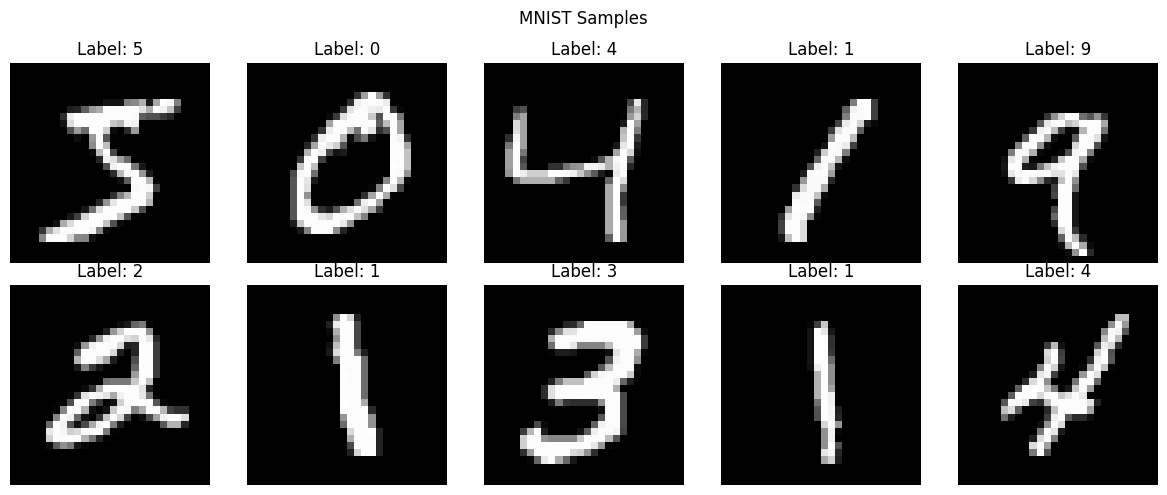

In [5]:
# Visualize a few samples
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_images[i], cmap='gray')
    ax.set_title(f'Label: {train_labels[i]}')
    ax.axis('off')
plt.suptitle('MNIST Samples')
plt.tight_layout()
plt.show()


In [6]:
# Save as flat binary files for CUDA to read easily
# Normalize to 0-1 range and flatten to 784 pixels per image

# Flatten and normalize
train_flat = train_images.reshape(60000, 784).astype(np.float32) / 255.0
test_flat = test_images.reshape(10000, 784).astype(np.float32) / 255.0
train_lab = train_labels.astype(np.int32)
test_lab = test_labels.astype(np.int32)

# Save as raw binary
train_flat.tofile('mnist/train_images.bin')
train_lab.tofile('mnist/train_labels.bin')
test_flat.tofile('mnist/test_images.bin')
test_lab.tofile('mnist/test_labels.bin')

print(f"Saved train_images.bin: {train_flat.nbytes / 1e6:.1f} MB ({train_flat.shape})")
print(f"Saved train_labels.bin: {train_lab.nbytes / 1e3:.1f} KB ({train_lab.shape})")
print(f"Saved test_images.bin:  {test_flat.nbytes / 1e6:.1f} MB ({test_flat.shape})")
print(f"Saved test_labels.bin:  {test_lab.nbytes / 1e3:.1f} KB ({test_lab.shape})")
print(f"\nEach image: 784 floats (28×28 pixels, normalized 0-1)")
print(f"Each label: 1 int (digit 0-9)")


Saved train_images.bin: 188.2 MB ((60000, 784))
Saved train_labels.bin: 240.0 KB ((60000,))
Saved test_images.bin:  31.4 MB ((10000, 784))
Saved test_labels.bin:  40.0 KB ((10000,))

Each image: 784 floats (28×28 pixels, normalized 0-1)
Each label: 1 int (digit 0-9)


In [8]:
# Show one image as both picture and numbers
idx = 0  # first image
img = train_images[idx]
label = train_labels[idx]

print(f"Label: {label}")
print(f"\nAs 28×28 grid (showing middle rows where digit is):")
for row in range(8, 20):
    line = ""
    for col in range(28):
        if img[row][col] > 200:
            line += "██"
        elif img[row][col] > 100:
            line += "░░"
        else:
            line += "  "
    print(f"  Row {row:2d}: {line}")

print(f"\nAs flat array (first 20 of 784 values, normalized):")
flat = img.reshape(784).astype(np.float32) / 255.0
print(f"  {flat[:20]}")
print(f"  ... ({784-20} more values) ...")
print(f"\nTotal: {len(flat)} numbers → this is what CUDA kernel receives")


Label: 5

As 28×28 grid (showing middle rows where digit is):
  Row  8:                 ████████████░░░░████                    
  Row  9:                   ░░░░██████      ░░                    
  Row 10:                       ░░██                              
  Row 11:                       ░░██░░                            
  Row 12:                         ░░██                            
  Row 13:                           ████░░░░                      
  Row 14:                             ██████░░                    
  Row 15:                               ░░████░░                  
  Row 16:                                   ████░░                
  Row 17:                                   ██████                
  Row 18:                               ░░░░██████                
  Row 19:                           ░░██████████░░                

As flat array (first 20 of 784 values, normalized):
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  ... (764 more v

In [9]:
%%writefile mlp_mnist.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <time.h>

// Network architecture
#define INPUT_SIZE 784
#define HIDDEN1_SIZE 128
#define HIDDEN2_SIZE 64
#define OUTPUT_SIZE 10
#define LEARNING_RATE 0.01f
#define BATCH_SIZE 64
#define EPOCHS 10

// ============ CUDA KERNELS ============

// Forward: Matrix multiply (input × weights) + bias
__global__ void linear_forward(float *input, float *weights, float *bias, float *output,
                               int batch, int in_size, int out_size) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;  // which sample in batch
    int col = blockIdx.x * blockDim.x + threadIdx.x;  // which output neuron

    if (row < batch && col < out_size) {
        float sum = bias[col];
        for (int i = 0; i < in_size; i++) {
            sum += input[row * in_size + i] * weights[i * out_size + col];
        }
        output[row * out_size + col] = sum;
    }
}

// Activation: ReLU (if negative → 0, if positive → keep)
__global__ void relu_forward(float *data, int size) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < size) {
        if (data[i] < 0) data[i] = 0;
    }
}

// Softmax (convert raw scores → probabilities that sum to 1)
__global__ void softmax_forward(float *input, float *output, int batch, int classes) {
    int row = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < batch) {
        // Find max for numerical stability
        float max_val = input[row * classes];
        for (int i = 1; i < classes; i++) {
            if (input[row * classes + i] > max_val)
                max_val = input[row * classes + i];
        }
        // Compute exp and sum
        float sum = 0;
        for (int i = 0; i < classes; i++) {
            output[row * classes + i] = expf(input[row * classes + i] - max_val);
            sum += output[row * classes + i];
        }
        // Normalize
        for (int i = 0; i < classes; i++) {
            output[row * classes + i] /= sum;
        }
    }
}

// Backward: Softmax + Cross-entropy gradient (combined)
// gradient = predicted - one_hot(label)
__global__ void softmax_backward(float *probs, int *labels, float *grad,
                                  int batch, int classes) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < batch && col < classes) {
        float target = (col == labels[row]) ? 1.0f : 0.0f;
        grad[row * classes + col] = (probs[row * classes + col] - target) / batch;
    }
}

// Backward: Compute weight gradients (dW = input^T × grad_output)
__global__ void linear_backward_weights(float *input, float *grad_output, float *grad_weights,
                                         int batch, int in_size, int out_size) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;  // input neuron
    int col = blockIdx.x * blockDim.x + threadIdx.x;  // output neuron
    if (row < in_size && col < out_size) {
        float sum = 0;
        for (int b = 0; b < batch; b++) {
            sum += input[b * in_size + row] * grad_output[b * out_size + col];
        }
        grad_weights[row * out_size + col] = sum;
    }
}

// Backward: Compute bias gradients (db = sum of grad_output over batch)
__global__ void linear_backward_bias(float *grad_output, float *grad_bias,
                                      int batch, int out_size) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (col < out_size) {
        float sum = 0;
        for (int b = 0; b < batch; b++) {
            sum += grad_output[b * out_size + col];
        }
        grad_bias[col] = sum;
    }
}

// Backward: Compute input gradients (dx = grad_output × weights^T)
__global__ void linear_backward_input(float *grad_output, float *weights, float *grad_input,
                                       int batch, int in_size, int out_size) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;  // batch
    int col = blockIdx.x * blockDim.x + threadIdx.x;  // input neuron
    if (row < batch && col < in_size) {
        float sum = 0;
        for (int i = 0; i < out_size; i++) {
            sum += grad_output[row * out_size + i] * weights[col * out_size + i];
        }
        grad_input[row * in_size + col] = sum;
    }
}

// Backward: ReLU gradient (pass gradient through if input was > 0)
__global__ void relu_backward(float *grad, float *original_output, int size) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < size) {
        if (original_output[i] <= 0) grad[i] = 0;
    }
}

// Update weights: W -= learning_rate * dW
__global__ void sgd_update(float *params, float *grads, float lr, int size) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < size) {
        params[i] -= lr * grads[i];
    }
}

// ============ HOST FUNCTIONS ============

void init_weights(float *w, int size) {
    float scale = sqrtf(2.0f / size);
    for (int i = 0; i < size; i++) {
        w[i] = ((float)rand() / RAND_MAX - 0.5f) * 2 * scale;
    }
}

int main() {
    srand(42);
    printf("=== MLP on MNIST (CUDA from scratch) ===\n");
    printf("Architecture: %d → %d → %d → %d\n", INPUT_SIZE, HIDDEN1_SIZE, HIDDEN2_SIZE, OUTPUT_SIZE);
    printf("Batch size: %d, Learning rate: %.3f, Epochs: %d\n\n", BATCH_SIZE, LEARNING_RATE, EPOCHS);

    // Load data
    FILE *f;
    float *h_train_images = (float*)malloc(60000 * 784 * sizeof(float));
    int *h_train_labels = (int*)malloc(60000 * sizeof(int));
    float *h_test_images = (float*)malloc(10000 * 784 * sizeof(float));
    int *h_test_labels = (int*)malloc(10000 * sizeof(int));

    f = fopen("mnist/train_images.bin", "rb"); fread(h_train_images, sizeof(float), 60000*784, f); fclose(f);
    f = fopen("mnist/train_labels.bin", "rb"); fread(h_train_labels, sizeof(int), 60000, f); fclose(f);
    f = fopen("mnist/test_images.bin", "rb"); fread(h_test_images, sizeof(float), 10000*784, f); fclose(f);
    f = fopen("mnist/test_labels.bin", "rb"); fread(h_test_labels, sizeof(int), 10000, f); fclose(f);
    printf("Data loaded: 60000 train, 10000 test\n");

    // Initialize weights on host
    int w1_size = INPUT_SIZE * HIDDEN1_SIZE;   // 784×128
    int w2_size = HIDDEN1_SIZE * HIDDEN2_SIZE; // 128×64
    int w3_size = HIDDEN2_SIZE * OUTPUT_SIZE;  // 64×10

    float *h_w1 = (float*)malloc(w1_size * sizeof(float));
    float *h_w2 = (float*)malloc(w2_size * sizeof(float));
    float *h_w3 = (float*)malloc(w3_size * sizeof(float));
    float *h_b1 = (float*)calloc(HIDDEN1_SIZE, sizeof(float));
    float *h_b2 = (float*)calloc(HIDDEN2_SIZE, sizeof(float));
    float *h_b3 = (float*)calloc(OUTPUT_SIZE, sizeof(float));

    init_weights(h_w1, w1_size);
    init_weights(h_w2, w2_size);
    init_weights(h_w3, w3_size);

    // Allocate GPU memory — weights
    float *d_w1, *d_w2, *d_w3, *d_b1, *d_b2, *d_b3;
    cudaMalloc(&d_w1, w1_size * sizeof(float));
    cudaMalloc(&d_w2, w2_size * sizeof(float));
    cudaMalloc(&d_w3, w3_size * sizeof(float));
    cudaMalloc(&d_b1, HIDDEN1_SIZE * sizeof(float));
    cudaMalloc(&d_b2, HIDDEN2_SIZE * sizeof(float));
    cudaMalloc(&d_b3, OUTPUT_SIZE * sizeof(float));

    cudaMemcpy(d_w1, h_w1, w1_size * sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_w2, h_w2, w2_size * sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_w3, h_w3, w3_size * sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_b1, h_b1, HIDDEN1_SIZE * sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_b2, h_b2, HIDDEN2_SIZE * sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_b3, h_b3, OUTPUT_SIZE * sizeof(float), cudaMemcpyHostToDevice);

    // Allocate GPU memory — activations and gradients
    float *d_input, *d_h1, *d_h1_relu, *d_h2, *d_h2_relu, *d_out, *d_probs;
    cudaMalloc(&d_input, BATCH_SIZE * INPUT_SIZE * sizeof(float));
    cudaMalloc(&d_h1, BATCH_SIZE * HIDDEN1_SIZE * sizeof(float));
    cudaMalloc(&d_h1_relu, BATCH_SIZE * HIDDEN1_SIZE * sizeof(float));
    cudaMalloc(&d_h2, BATCH_SIZE * HIDDEN2_SIZE * sizeof(float));
    cudaMalloc(&d_h2_relu, BATCH_SIZE * HIDDEN2_SIZE * sizeof(float));
    cudaMalloc(&d_out, BATCH_SIZE * OUTPUT_SIZE * sizeof(float));
    cudaMalloc(&d_probs, BATCH_SIZE * OUTPUT_SIZE * sizeof(float));

    int *d_labels;
    cudaMalloc(&d_labels, BATCH_SIZE * sizeof(int));

    // Gradients
    float *d_grad_out, *d_grad_h2, *d_grad_h1;
    float *d_grad_w1, *d_grad_w2, *d_grad_w3;
    float *d_grad_b1, *d_grad_b2, *d_grad_b3;
    cudaMalloc(&d_grad_out, BATCH_SIZE * OUTPUT_SIZE * sizeof(float));
    cudaMalloc(&d_grad_h2, BATCH_SIZE * HIDDEN2_SIZE * sizeof(float));
    cudaMalloc(&d_grad_h1, BATCH_SIZE * HIDDEN1_SIZE * sizeof(float));
    cudaMalloc(&d_grad_w1, w1_size * sizeof(float));
    cudaMalloc(&d_grad_w2, w2_size * sizeof(float));
    cudaMalloc(&d_grad_w3, w3_size * sizeof(float));
    cudaMalloc(&d_grad_b1, HIDDEN1_SIZE * sizeof(float));
    cudaMalloc(&d_grad_b2, HIDDEN2_SIZE * sizeof(float));
    cudaMalloc(&d_grad_b3, OUTPUT_SIZE * sizeof(float));

    printf("GPU memory allocated\n\n");

    // Training loop
    int num_batches = 60000 / BATCH_SIZE;
    dim3 threads(16, 16);

    for (int epoch = 0; epoch < EPOCHS; epoch++) {
        float total_loss = 0;
        int correct = 0;

        for (int batch = 0; batch < num_batches; batch++) {
            int offset = batch * BATCH_SIZE;

            // Copy batch to GPU
            cudaMemcpy(d_input, &h_train_images[offset * INPUT_SIZE],
                       BATCH_SIZE * INPUT_SIZE * sizeof(float), cudaMemcpyHostToDevice);
            cudaMemcpy(d_labels, &h_train_labels[offset],
                       BATCH_SIZE * sizeof(int), cudaMemcpyHostToDevice);

            // ===== FORWARD PASS =====
            // Layer 1: input(64×784) × W1(784×128) + b1 → h1(64×128)
            dim3 b1((HIDDEN1_SIZE+15)/16, (BATCH_SIZE+15)/16);
            linear_forward<<<b1, threads>>>(d_input, d_w1, d_b1, d_h1,
                                            BATCH_SIZE, INPUT_SIZE, HIDDEN1_SIZE);
            // Save pre-ReLU for backward
            cudaMemcpy(d_h1_relu, d_h1, BATCH_SIZE * HIDDEN1_SIZE * sizeof(float), cudaMemcpyDeviceToDevice);
            // ReLU
            int relu1_size = BATCH_SIZE * HIDDEN1_SIZE;
            relu_forward<<<(relu1_size+255)/256, 256>>>(d_h1, relu1_size);

            // Layer 2: h1(64×128) × W2(128×64) + b2 → h2(64×64)
            dim3 b2((HIDDEN2_SIZE+15)/16, (BATCH_SIZE+15)/16);
            linear_forward<<<b2, threads>>>(d_h1, d_w2, d_b2, d_h2,
                                            BATCH_SIZE, HIDDEN1_SIZE, HIDDEN2_SIZE);
            cudaMemcpy(d_h2_relu, d_h2, BATCH_SIZE * HIDDEN2_SIZE * sizeof(float), cudaMemcpyDeviceToDevice);
            int relu2_size = BATCH_SIZE * HIDDEN2_SIZE;
            relu_forward<<<(relu2_size+255)/256, 256>>>(d_h2, relu2_size);

            // Layer 3: h2(64×64) × W3(64×10) + b3 → out(64×10)
            dim3 b3((OUTPUT_SIZE+15)/16, (BATCH_SIZE+15)/16);
            linear_forward<<<b3, threads>>>(d_h2, d_w3, d_b3, d_out,
                                            BATCH_SIZE, HIDDEN2_SIZE, OUTPUT_SIZE);

            // Softmax
            softmax_forward<<<(BATCH_SIZE+255)/256, 256>>>(d_out, d_probs, BATCH_SIZE, OUTPUT_SIZE);

            // ===== BACKWARD PASS =====
            // Output gradient: dL/d_out = probs - one_hot(labels)
            dim3 bg3((OUTPUT_SIZE+15)/16, (BATCH_SIZE+15)/16);
            softmax_backward<<<bg3, threads>>>(d_probs, d_labels, d_grad_out,
                                               BATCH_SIZE, OUTPUT_SIZE);

            // Layer 3 gradients
            dim3 bw3((OUTPUT_SIZE+15)/16, (HIDDEN2_SIZE+15)/16);
            linear_backward_weights<<<bw3, threads>>>(d_h2, d_grad_out, d_grad_w3,
                                                      BATCH_SIZE, HIDDEN2_SIZE, OUTPUT_SIZE);
            linear_backward_bias<<<(OUTPUT_SIZE+255)/256, 256>>>(d_grad_out, d_grad_b3,
                                                                  BATCH_SIZE, OUTPUT_SIZE);
            dim3 bi2((HIDDEN2_SIZE+15)/16, (BATCH_SIZE+15)/16);
            linear_backward_input<<<bi2, threads>>>(d_grad_out, d_w3, d_grad_h2,
                                                    BATCH_SIZE, HIDDEN2_SIZE, OUTPUT_SIZE);

            // ReLU backward for layer 2
            relu_backward<<<(relu2_size+255)/256, 256>>>(d_grad_h2, d_h2_relu, relu2_size);

            // Layer 2 gradients
            dim3 bw2((HIDDEN2_SIZE+15)/16, (HIDDEN1_SIZE+15)/16);
            linear_backward_weights<<<bw2, threads>>>(d_h1, d_grad_h2, d_grad_w2,
                                                      BATCH_SIZE, HIDDEN1_SIZE, HIDDEN2_SIZE);
            linear_backward_bias<<<(HIDDEN2_SIZE+255)/256, 256>>>(d_grad_h2, d_grad_b2,
                                                                   BATCH_SIZE, HIDDEN2_SIZE);
            dim3 bi1((HIDDEN1_SIZE+15)/16, (BATCH_SIZE+15)/16);
            linear_backward_input<<<bi1, threads>>>(d_grad_h2, d_w2, d_grad_h1,
                                                    BATCH_SIZE, HIDDEN1_SIZE, HIDDEN2_SIZE);

            // ReLU backward for layer 1
            relu_backward<<<(relu1_size+255)/256, 256>>>(d_grad_h1, d_h1_relu, relu1_size);

            // Layer 1 gradients
            dim3 bw1((HIDDEN1_SIZE+15)/16, (INPUT_SIZE+15)/16);
            linear_backward_weights<<<bw1, threads>>>(d_input, d_grad_h1, d_grad_w1,
                                                      BATCH_SIZE, INPUT_SIZE, HIDDEN1_SIZE);
            linear_backward_bias<<<(HIDDEN1_SIZE+255)/256, 256>>>(d_grad_h1, d_grad_b1,
                                                                   BATCH_SIZE, HIDDEN1_SIZE);

            // ===== UPDATE WEIGHTS (SGD) =====
            sgd_update<<<(w1_size+255)/256, 256>>>(d_w1, d_grad_w1, LEARNING_RATE, w1_size);
            sgd_update<<<(w2_size+255)/256, 256>>>(d_w2, d_grad_w2, LEARNING_RATE, w2_size);
            sgd_update<<<(w3_size+255)/256, 256>>>(d_w3, d_grad_w3, LEARNING_RATE, w3_size);
            sgd_update<<<(HIDDEN1_SIZE+255)/256, 256>>>(d_b1, d_grad_b1, LEARNING_RATE, HIDDEN1_SIZE);
            sgd_update<<<(HIDDEN2_SIZE+255)/256, 256>>>(d_b2, d_grad_b2, LEARNING_RATE, HIDDEN2_SIZE);
            sgd_update<<<(OUTPUT_SIZE+255)/256, 256>>>(d_b3, d_grad_b3, LEARNING_RATE, OUTPUT_SIZE);

            // Track accuracy (every 100 batches)
            if (batch % 100 == 0) {
                float h_probs[BATCH_SIZE * OUTPUT_SIZE];
                cudaMemcpy(h_probs, d_probs, BATCH_SIZE * OUTPUT_SIZE * sizeof(float), cudaMemcpyDeviceToHost);
                int batch_correct = 0;
                for (int s = 0; s < BATCH_SIZE; s++) {
                    int pred = 0;
                    float max_p = h_probs[s * OUTPUT_SIZE];
                    for (int c = 1; c < OUTPUT_SIZE; c++) {
                        if (h_probs[s * OUTPUT_SIZE + c] > max_p) {
                            max_p = h_probs[s * OUTPUT_SIZE + c];
                            pred = c;
                        }
                    }
                    if (pred == h_train_labels[offset + s]) batch_correct++;
                }
                correct += batch_correct;
            }
        }

        // Test accuracy
        int test_correct = 0;
        for (int i = 0; i < 10000; i += BATCH_SIZE) {
            cudaMemcpy(d_input, &h_test_images[i * INPUT_SIZE],
                       BATCH_SIZE * INPUT_SIZE * sizeof(float), cudaMemcpyHostToDevice);

            dim3 b1((HIDDEN1_SIZE+15)/16, (BATCH_SIZE+15)/16);
            linear_forward<<<b1, threads>>>(d_input, d_w1, d_b1, d_h1,
                                            BATCH_SIZE, INPUT_SIZE, HIDDEN1_SIZE);
            relu_forward<<<(BATCH_SIZE*HIDDEN1_SIZE+255)/256, 256>>>(d_h1, BATCH_SIZE*HIDDEN1_SIZE);

            dim3 b2((HIDDEN2_SIZE+15)/16, (BATCH_SIZE+15)/16);
            linear_forward<<<b2, threads>>>(d_h1, d_w2, d_b2, d_h2,
                                            BATCH_SIZE, HIDDEN1_SIZE, HIDDEN2_SIZE);
            relu_forward<<<(BATCH_SIZE*HIDDEN2_SIZE+255)/256, 256>>>(d_h2, BATCH_SIZE*HIDDEN2_SIZE);

            dim3 b3((OUTPUT_SIZE+15)/16, (BATCH_SIZE+15)/16);
            linear_forward<<<b3, threads>>>(d_h2, d_w3, d_b3, d_out,
                                            BATCH_SIZE, HIDDEN2_SIZE, OUTPUT_SIZE);
            softmax_forward<<<(BATCH_SIZE+255)/256, 256>>>(d_out, d_probs, BATCH_SIZE, OUTPUT_SIZE);

            float h_probs[BATCH_SIZE * OUTPUT_SIZE];
            cudaMemcpy(h_probs, d_probs, BATCH_SIZE * OUTPUT_SIZE * sizeof(float), cudaMemcpyDeviceToHost);

            for (int s = 0; s < BATCH_SIZE && (i+s) < 10000; s++) {
                int pred = 0;
                float max_p = h_probs[s * OUTPUT_SIZE];
                for (int c = 1; c < OUTPUT_SIZE; c++) {
                    if (h_probs[s * OUTPUT_SIZE + c] > max_p) {
                        max_p = h_probs[s * OUTPUT_SIZE + c];
                        pred = c;
                    }
                }
                if (pred == h_test_labels[i + s]) test_correct++;
            }
        }

        printf("Epoch %2d | Test Accuracy: %.2f%% (%d/10000)\n",
               epoch + 1, 100.0f * test_correct / 10000, test_correct);
    }

    printf("\nTraining complete!\n");

    // Cleanup
    free(h_train_images); free(h_train_labels);
    free(h_test_images); free(h_test_labels);
    free(h_w1); free(h_w2); free(h_w3);
    free(h_b1); free(h_b2); free(h_b3);
    cudaFree(d_w1); cudaFree(d_w2); cudaFree(d_w3);
    cudaFree(d_b1); cudaFree(d_b2); cudaFree(d_b3);
    cudaFree(d_input); cudaFree(d_h1); cudaFree(d_h1_relu);
    cudaFree(d_h2); cudaFree(d_h2_relu);
    cudaFree(d_out); cudaFree(d_probs); cudaFree(d_labels);
    cudaFree(d_grad_out); cudaFree(d_grad_h2); cudaFree(d_grad_h1);
    cudaFree(d_grad_w1); cudaFree(d_grad_w2); cudaFree(d_grad_w3);
    cudaFree(d_grad_b1); cudaFree(d_grad_b2); cudaFree(d_grad_b3);

    return 0;
}


Writing mlp_mnist.cu


In [10]:
!nvcc mlp_mnist.cu -o mlp_mnist -lm && ./mlp_mnist


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
mlp_mnist.cu(226): warning #177-D: variable "total_loss" was declared but never referenced
          float total_loss = 0;
                ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

=== MLP on MNIST (CUDA from scratch) ===
Architecture: 784 → 128 → 64 → 10
Batch size: 64, Learning rate: 0.010, Epochs: 10

Data loaded: 60000 train, 10000 test
GPU memory allocated

Epoch  1 | Test Accuracy: 11.35% (1135/10000)
Epoch  2 | Test Accuracy: 38.77% (3877/10000)
Epoch  3 | Test Accuracy: 72.50% (7250/10000)
Epoch  4 | Test Accuracy: 81.30% (8130/10000)
Epoch  5 | Test Accuracy: 85.21% (8521/10000)
Epoch  6 | Test Accuracy: 87.27% (8727/10000)
Epoch  7 | Test Accuracy: 88.70% (8870/10000)
Epoch  8 | Test Accuracy: 89.59% (8959/10000)
Epoch  9 | Test Accuracy: 90.22% (9022/1

In [4]:
%%writefile mlp_mnist_v2.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>

// Improved hyperparameters
#define INPUT_SIZE 784
#define HIDDEN1_SIZE 256
#define HIDDEN2_SIZE 128
#define OUTPUT_SIZE 10
#define LEARNING_RATE 0.005f
#define BATCH_SIZE 128
#define EPOCHS 20

// Same kernels as before (copy from mlp_mnist.cu)
__global__ void linear_forward(float *input, float *weights, float *bias, float *output,
                               int batch, int in_size, int out_size) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < batch && col < out_size) {
        float sum = bias[col];
        for (int i = 0; i < in_size; i++)
            sum += input[row * in_size + i] * weights[i * out_size + col];
        output[row * out_size + col] = sum;
    }
}

__global__ void relu_forward(float *data, int size) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < size) { if (data[i] < 0) data[i] = 0; }
}

__global__ void softmax_forward(float *input, float *output, int batch, int classes) {
    int row = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < batch) {
        float max_val = input[row * classes];
        for (int i = 1; i < classes; i++)
            if (input[row * classes + i] > max_val) max_val = input[row * classes + i];
        float sum = 0;
        for (int i = 0; i < classes; i++) {
            output[row * classes + i] = expf(input[row * classes + i] - max_val);
            sum += output[row * classes + i];
        }
        for (int i = 0; i < classes; i++)
            output[row * classes + i] /= sum;
    }
}

__global__ void softmax_backward(float *probs, int *labels, float *grad, int batch, int classes) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < batch && col < classes) {
        float target = (col == labels[row]) ? 1.0f : 0.0f;
        grad[row * classes + col] = (probs[row * classes + col] - target) / batch;
    }
}

__global__ void linear_backward_weights(float *input, float *grad_output, float *grad_weights,
                                         int batch, int in_size, int out_size) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < in_size && col < out_size) {
        float sum = 0;
        for (int b = 0; b < batch; b++)
            sum += input[b * in_size + row] * grad_output[b * out_size + col];
        grad_weights[row * out_size + col] = sum;
    }
}

__global__ void linear_backward_bias(float *grad_output, float *grad_bias, int batch, int out_size) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (col < out_size) {
        float sum = 0;
        for (int b = 0; b < batch; b++)
            sum += grad_output[b * out_size + col];
        grad_bias[col] = sum;
    }
}

__global__ void linear_backward_input(float *grad_output, float *weights, float *grad_input,
                                       int batch, int in_size, int out_size) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < batch && col < in_size) {
        float sum = 0;
        for (int i = 0; i < out_size; i++)
            sum += grad_output[row * out_size + i] * weights[col * out_size + i];
        grad_input[row * in_size + col] = sum;
    }
}

__global__ void relu_backward(float *grad, float *original_output, int size) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < size) { if (original_output[i] <= 0) grad[i] = 0; }
}

__global__ void sgd_update(float *params, float *grads, float lr, int size) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < size) { params[i] -= lr * grads[i]; }
}

void init_weights(float *w, int fan_in, int size) {
    float scale = sqrtf(2.0f / fan_in);
    for (int i = 0; i < size; i++)
        w[i] = ((float)rand() / RAND_MAX - 0.5f) * 2 * scale;
}

int main() {
    srand(42);
    printf("=== MLP on MNIST v2 (Improved) ===\n");
    printf("Architecture: %d → %d → %d → %d\n", INPUT_SIZE, HIDDEN1_SIZE, HIDDEN2_SIZE, OUTPUT_SIZE);
    printf("Batch: %d, LR: %.4f, Epochs: %d\n\n", BATCH_SIZE, LEARNING_RATE, EPOCHS);

    // Load data
    float *h_train_images = (float*)malloc(60000 * 784 * sizeof(float));
    int *h_train_labels = (int*)malloc(60000 * sizeof(int));
    float *h_test_images = (float*)malloc(10000 * 784 * sizeof(float));
    int *h_test_labels = (int*)malloc(10000 * sizeof(int));

    FILE *f;
    f = fopen("mnist/train_images.bin", "rb"); fread(h_train_images, sizeof(float), 60000*784, f); fclose(f);
    f = fopen("mnist/train_labels.bin", "rb"); fread(h_train_labels, sizeof(int), 60000, f); fclose(f);
    f = fopen("mnist/test_images.bin", "rb"); fread(h_test_images, sizeof(float), 10000*784, f); fclose(f);
    f = fopen("mnist/test_labels.bin", "rb"); fread(h_test_labels, sizeof(int), 10000, f); fclose(f);

    // Initialize weights
    int w1_size = INPUT_SIZE * HIDDEN1_SIZE;
    int w2_size = HIDDEN1_SIZE * HIDDEN2_SIZE;
    int w3_size = HIDDEN2_SIZE * OUTPUT_SIZE;

    float *h_w1 = (float*)malloc(w1_size * sizeof(float));
    float *h_w2 = (float*)malloc(w2_size * sizeof(float));
    float *h_w3 = (float*)malloc(w3_size * sizeof(float));
    float *h_b1 = (float*)calloc(HIDDEN1_SIZE, sizeof(float));
    float *h_b2 = (float*)calloc(HIDDEN2_SIZE, sizeof(float));
    float *h_b3 = (float*)calloc(OUTPUT_SIZE, sizeof(float));

    init_weights(h_w1, INPUT_SIZE, w1_size);
    init_weights(h_w2, HIDDEN1_SIZE, w2_size);
    init_weights(h_w3, HIDDEN2_SIZE, w3_size);

    // GPU memory — weights
    float *d_w1, *d_w2, *d_w3, *d_b1, *d_b2, *d_b3;
    cudaMalloc(&d_w1, w1_size*sizeof(float)); cudaMalloc(&d_w2, w2_size*sizeof(float));
    cudaMalloc(&d_w3, w3_size*sizeof(float));
    cudaMalloc(&d_b1, HIDDEN1_SIZE*sizeof(float)); cudaMalloc(&d_b2, HIDDEN2_SIZE*sizeof(float));
    cudaMalloc(&d_b3, OUTPUT_SIZE*sizeof(float));

    cudaMemcpy(d_w1, h_w1, w1_size*sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_w2, h_w2, w2_size*sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_w3, h_w3, w3_size*sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_b1, h_b1, HIDDEN1_SIZE*sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_b2, h_b2, HIDDEN2_SIZE*sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_b3, h_b3, OUTPUT_SIZE*sizeof(float), cudaMemcpyHostToDevice);

    // GPU memory — activations
    float *d_input, *d_h1, *d_h1_relu, *d_h2, *d_h2_relu, *d_out, *d_probs;
    cudaMalloc(&d_input, BATCH_SIZE*INPUT_SIZE*sizeof(float));
    cudaMalloc(&d_h1, BATCH_SIZE*HIDDEN1_SIZE*sizeof(float));
    cudaMalloc(&d_h1_relu, BATCH_SIZE*HIDDEN1_SIZE*sizeof(float));
    cudaMalloc(&d_h2, BATCH_SIZE*HIDDEN2_SIZE*sizeof(float));
    cudaMalloc(&d_h2_relu, BATCH_SIZE*HIDDEN2_SIZE*sizeof(float));
    cudaMalloc(&d_out, BATCH_SIZE*OUTPUT_SIZE*sizeof(float));
    cudaMalloc(&d_probs, BATCH_SIZE*OUTPUT_SIZE*sizeof(float));
    int *d_labels; cudaMalloc(&d_labels, BATCH_SIZE*sizeof(int));

    // GPU memory — gradients
    float *d_grad_out, *d_grad_h2, *d_grad_h1;
    float *d_grad_w1, *d_grad_w2, *d_grad_w3, *d_grad_b1, *d_grad_b2, *d_grad_b3;
    cudaMalloc(&d_grad_out, BATCH_SIZE*OUTPUT_SIZE*sizeof(float));
    cudaMalloc(&d_grad_h2, BATCH_SIZE*HIDDEN2_SIZE*sizeof(float));
    cudaMalloc(&d_grad_h1, BATCH_SIZE*HIDDEN1_SIZE*sizeof(float));
    cudaMalloc(&d_grad_w1, w1_size*sizeof(float)); cudaMalloc(&d_grad_w2, w2_size*sizeof(float));
    cudaMalloc(&d_grad_w3, w3_size*sizeof(float));
    cudaMalloc(&d_grad_b1, HIDDEN1_SIZE*sizeof(float)); cudaMalloc(&d_grad_b2, HIDDEN2_SIZE*sizeof(float));
    cudaMalloc(&d_grad_b3, OUTPUT_SIZE*sizeof(float));

    printf("Data loaded, GPU ready\n\n");

    // Training
    int num_batches = 60000 / BATCH_SIZE;
    dim3 threads(16, 16);

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);
    cudaEventRecord(start);

    for (int epoch = 0; epoch < EPOCHS; epoch++) {
        for (int batch = 0; batch < num_batches; batch++) {
            int offset = batch * BATCH_SIZE;
            cudaMemcpy(d_input, &h_train_images[offset*INPUT_SIZE], BATCH_SIZE*INPUT_SIZE*sizeof(float), cudaMemcpyHostToDevice);
            cudaMemcpy(d_labels, &h_train_labels[offset], BATCH_SIZE*sizeof(int), cudaMemcpyHostToDevice);

            // Forward
            dim3 bl1((HIDDEN1_SIZE+15)/16, (BATCH_SIZE+15)/16);
            linear_forward<<<bl1,threads>>>(d_input, d_w1, d_b1, d_h1, BATCH_SIZE, INPUT_SIZE, HIDDEN1_SIZE);
            cudaMemcpy(d_h1_relu, d_h1, BATCH_SIZE*HIDDEN1_SIZE*sizeof(float), cudaMemcpyDeviceToDevice);
            relu_forward<<<(BATCH_SIZE*HIDDEN1_SIZE+255)/256, 256>>>(d_h1, BATCH_SIZE*HIDDEN1_SIZE);

            dim3 bl2((HIDDEN2_SIZE+15)/16, (BATCH_SIZE+15)/16);
            linear_forward<<<bl2,threads>>>(d_h1, d_w2, d_b2, d_h2, BATCH_SIZE, HIDDEN1_SIZE, HIDDEN2_SIZE);
            cudaMemcpy(d_h2_relu, d_h2, BATCH_SIZE*HIDDEN2_SIZE*sizeof(float), cudaMemcpyDeviceToDevice);
            relu_forward<<<(BATCH_SIZE*HIDDEN2_SIZE+255)/256, 256>>>(d_h2, BATCH_SIZE*HIDDEN2_SIZE);

            dim3 bl3((OUTPUT_SIZE+15)/16, (BATCH_SIZE+15)/16);
            linear_forward<<<bl3,threads>>>(d_h2, d_w3, d_b3, d_out, BATCH_SIZE, HIDDEN2_SIZE, OUTPUT_SIZE);
            softmax_forward<<<(BATCH_SIZE+255)/256, 256>>>(d_out, d_probs, BATCH_SIZE, OUTPUT_SIZE);

            // Backward
            dim3 bg3((OUTPUT_SIZE+15)/16, (BATCH_SIZE+15)/16);
            softmax_backward<<<bg3,threads>>>(d_probs, d_labels, d_grad_out, BATCH_SIZE, OUTPUT_SIZE);

            dim3 bw3((OUTPUT_SIZE+15)/16, (HIDDEN2_SIZE+15)/16);
            linear_backward_weights<<<bw3,threads>>>(d_h2, d_grad_out, d_grad_w3, BATCH_SIZE, HIDDEN2_SIZE, OUTPUT_SIZE);
            linear_backward_bias<<<(OUTPUT_SIZE+255)/256, 256>>>(d_grad_out, d_grad_b3, BATCH_SIZE, OUTPUT_SIZE);
            dim3 bi2((HIDDEN2_SIZE+15)/16, (BATCH_SIZE+15)/16);
            linear_backward_input<<<bi2,threads>>>(d_grad_out, d_w3, d_grad_h2, BATCH_SIZE, HIDDEN2_SIZE, OUTPUT_SIZE);
            relu_backward<<<(BATCH_SIZE*HIDDEN2_SIZE+255)/256, 256>>>(d_grad_h2, d_h2_relu, BATCH_SIZE*HIDDEN2_SIZE);

            dim3 bw2((HIDDEN2_SIZE+15)/16, (HIDDEN1_SIZE+15)/16);
            linear_backward_weights<<<bw2,threads>>>(d_h1, d_grad_h2, d_grad_w2, BATCH_SIZE, HIDDEN1_SIZE, HIDDEN2_SIZE);
            linear_backward_bias<<<(HIDDEN2_SIZE+255)/256, 256>>>(d_grad_h2, d_grad_b2, BATCH_SIZE, HIDDEN2_SIZE);
            dim3 bi1((HIDDEN1_SIZE+15)/16, (BATCH_SIZE+15)/16);
            linear_backward_input<<<bi1,threads>>>(d_grad_h2, d_w2, d_grad_h1, BATCH_SIZE, HIDDEN1_SIZE, HIDDEN2_SIZE);
            relu_backward<<<(BATCH_SIZE*HIDDEN1_SIZE+255)/256, 256>>>(d_grad_h1, d_h1_relu, BATCH_SIZE*HIDDEN1_SIZE);

            dim3 bw1((HIDDEN1_SIZE+15)/16, (INPUT_SIZE+15)/16);
            linear_backward_weights<<<bw1,threads>>>(d_input, d_grad_h1, d_grad_w1, BATCH_SIZE, INPUT_SIZE, HIDDEN1_SIZE);
            linear_backward_bias<<<(HIDDEN1_SIZE+255)/256, 256>>>(d_grad_h1, d_grad_b1, BATCH_SIZE, HIDDEN1_SIZE);

            // Update
            sgd_update<<<(w1_size+255)/256, 256>>>(d_w1, d_grad_w1, LEARNING_RATE, w1_size);
            sgd_update<<<(w2_size+255)/256, 256>>>(d_w2, d_grad_w2, LEARNING_RATE, w2_size);
            sgd_update<<<(w3_size+255)/256, 256>>>(d_w3, d_grad_w3, LEARNING_RATE, w3_size);
            sgd_update<<<(HIDDEN1_SIZE+255)/256, 256>>>(d_b1, d_grad_b1, LEARNING_RATE, HIDDEN1_SIZE);
            sgd_update<<<(HIDDEN2_SIZE+255)/256, 256>>>(d_b2, d_grad_b2, LEARNING_RATE, HIDDEN2_SIZE);
            sgd_update<<<(OUTPUT_SIZE+255)/256, 256>>>(d_b3, d_grad_b3, LEARNING_RATE, OUTPUT_SIZE);
        }

        // Test accuracy every 5 epochs
        if ((epoch+1) % 2 == 0 || epoch == 0) {
            int test_correct = 0;
            for (int i = 0; i < 10000; i += BATCH_SIZE) {
                int count = (i + BATCH_SIZE <= 10000) ? BATCH_SIZE : 10000 - i;
                cudaMemcpy(d_input, &h_test_images[i*INPUT_SIZE], count*INPUT_SIZE*sizeof(float), cudaMemcpyHostToDevice);

                dim3 bl1((HIDDEN1_SIZE+15)/16, (BATCH_SIZE+15)/16);
                linear_forward<<<bl1,threads>>>(d_input, d_w1, d_b1, d_h1, count, INPUT_SIZE, HIDDEN1_SIZE);
                relu_forward<<<(count*HIDDEN1_SIZE+255)/256, 256>>>(d_h1, count*HIDDEN1_SIZE);
                dim3 bl2((HIDDEN2_SIZE+15)/16, (BATCH_SIZE+15)/16);
                linear_forward<<<bl2,threads>>>(d_h1, d_w2, d_b2, d_h2, count, HIDDEN1_SIZE, HIDDEN2_SIZE);
                relu_forward<<<(count*HIDDEN2_SIZE+255)/256, 256>>>(d_h2, count*HIDDEN2_SIZE);
                dim3 bl3((OUTPUT_SIZE+15)/16, (BATCH_SIZE+15)/16);
                linear_forward<<<bl3,threads>>>(d_h2, d_w3, d_b3, d_out, count, HIDDEN2_SIZE, OUTPUT_SIZE);
                softmax_forward<<<(count+255)/256, 256>>>(d_out, d_probs, count, OUTPUT_SIZE);

                float *h_probs = (float*)malloc(count*OUTPUT_SIZE*sizeof(float));
                cudaMemcpy(h_probs, d_probs, count*OUTPUT_SIZE*sizeof(float), cudaMemcpyDeviceToHost);
                for (int s = 0; s < count; s++) {
                    int pred = 0; float max_p = h_probs[s*OUTPUT_SIZE];
                    for (int c = 1; c < OUTPUT_SIZE; c++)
                        if (h_probs[s*OUTPUT_SIZE+c] > max_p) { max_p = h_probs[s*OUTPUT_SIZE+c]; pred = c; }
                    if (pred == h_test_labels[i+s]) test_correct++;
                }
                free(h_probs);
            }
            printf("Epoch %2d | Test Accuracy: %.2f%% (%d/10000)\n", epoch+1, 100.0f*test_correct/10000, test_correct);
        }
    }

    cudaEventRecord(stop); cudaEventSynchronize(stop);
    float total_ms; cudaEventElapsedTime(&total_ms, start, stop);
    printf("\nTotal training time: %.1f seconds\n", total_ms/1000);
    printf("Parameters: %d\n", w1_size + HIDDEN1_SIZE + w2_size + HIDDEN2_SIZE + w3_size + OUTPUT_SIZE);

    // Cleanup
    free(h_train_images); free(h_train_labels); free(h_test_images); free(h_test_labels);
    free(h_w1); free(h_w2); free(h_w3); free(h_b1); free(h_b2); free(h_b3);
    cudaFree(d_w1); cudaFree(d_w2); cudaFree(d_w3);
    cudaFree(d_b1); cudaFree(d_b2); cudaFree(d_b3);
    cudaFree(d_input); cudaFree(d_h1); cudaFree(d_h1_relu);
    cudaFree(d_h2); cudaFree(d_h2_relu); cudaFree(d_out); cudaFree(d_probs);
    cudaFree(d_labels);
    cudaFree(d_grad_out); cudaFree(d_grad_h2); cudaFree(d_grad_h1);
    cudaFree(d_grad_w1); cudaFree(d_grad_w2); cudaFree(d_grad_w3);
    cudaFree(d_grad_b1); cudaFree(d_grad_b2); cudaFree(d_grad_b3);
    return 0;
}


Overwriting mlp_mnist_v2.cu


In [5]:
!nvcc mlp_mnist_v2.cu -o mlp_mnist_v2 -lm && ./mlp_mnist_v2


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
=== MLP on MNIST v2 (Improved) ===
Architecture: 784 → 256 → 128 → 10
Batch: 128, LR: 0.0050, Epochs: 20



In [6]:
!ls -la mnist/*.bin


ls: cannot access 'mnist/*.bin': No such file or directory


In [8]:
!./mlp_mnist_v2 2>&1


=== MLP on MNIST v2 (Improved) ===
Architecture: 784 → 256 → 128 → 10
Batch: 128, LR: 0.0050, Epochs: 20

/bin/bash: line 1:  5913 Segmentation fault      (core dumped) ./mlp_mnist_v2 2>&1


In [9]:
# Quick test: does the original v1 still work?
!./mlp_mnist


/bin/bash: line 1: ./mlp_mnist: No such file or directory


In [10]:
import numpy as np
from torchvision import datasets
import os

os.makedirs('mnist', exist_ok=True)
train_data = datasets.MNIST('mnist', train=True, download=True)
test_data = datasets.MNIST('mnist', train=False, download=True)

train_images = train_data.data.numpy()
train_labels = train_data.targets.numpy()
test_images = test_data.data.numpy()
test_labels = test_data.targets.numpy()

# Flatten and normalize
train_flat = train_images.reshape(60000, 784).astype(np.float32) / 255.0
test_flat = test_images.reshape(10000, 784).astype(np.float32) / 255.0
train_lab = train_labels.astype(np.int32)
test_lab = test_labels.astype(np.int32)

# Save as binary
train_flat.tofile('mnist/train_images.bin')
train_lab.tofile('mnist/train_labels.bin')
test_flat.tofile('mnist/test_images.bin')
test_lab.tofile('mnist/test_labels.bin')

print("✓ Binary files created")
!ls -la mnist/*.bin


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 536kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.29MB/s]


✓ Binary files created
-rw-r--r-- 1 root root  31360000 May 24 21:41 mnist/test_images.bin
-rw-r--r-- 1 root root     40000 May 24 21:41 mnist/test_labels.bin
-rw-r--r-- 1 root root 188160000 May 24 21:41 mnist/train_images.bin
-rw-r--r-- 1 root root    240000 May 24 21:41 mnist/train_labels.bin


In [11]:
!./mlp_mnist_v2


=== MLP on MNIST v2 (Improved) ===
Architecture: 784 → 256 → 128 → 10
Batch: 128, LR: 0.0050, Epochs: 20

Data loaded, GPU ready

Epoch  1 | Test Accuracy: 69.26% (6926/10000)
Epoch  2 | Test Accuracy: 78.94% (7894/10000)
Epoch  4 | Test Accuracy: 86.77% (8677/10000)
Epoch  6 | Test Accuracy: 89.07% (8907/10000)
Epoch  8 | Test Accuracy: 89.93% (8993/10000)
Epoch 10 | Test Accuracy: 90.48% (9048/10000)
Epoch 12 | Test Accuracy: 90.90% (9090/10000)
Epoch 14 | Test Accuracy: 91.38% (9138/10000)
Epoch 16 | Test Accuracy: 91.82% (9182/10000)
Epoch 18 | Test Accuracy: 92.11% (9211/10000)
Epoch 20 | Test Accuracy: 92.55% (9255/10000)

Total training time: 4.8 seconds
Parameters: 235146


In [12]:
!nvcc mlp_mnist_v2.cu -o mlp_mnist_v2 -lm && ./mlp_mnist_v2


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
=== MLP on MNIST v2 (Improved) ===
Architecture: 784 → 256 → 128 → 10
Batch: 128, LR: 0.0050, Epochs: 20

Data loaded, GPU ready

Epoch  1 | Test Accuracy: 69.26% (6926/10000)
Epoch  2 | Test Accuracy: 78.94% (7894/10000)
Epoch  4 | Test Accuracy: 86.77% (8677/10000)
Epoch  6 | Test Accuracy: 89.07% (8907/10000)
Epoch  8 | Test Accuracy: 89.93% (8993/10000)
Epoch 10 | Test Accuracy: 90.48% (9048/10000)
Epoch 12 | Test Accuracy: 90.90% (9090/10000)
Epoch 14 | Test Accuracy: 91.38% (9138/10000)
Epoch 16 | Test Accuracy: 91.82% (9182/10000)
Epoch 18 | Test Accuracy: 92.11% (9211/10000)
Epoch 20 | Test Accuracy: 92.55% (9255/10000)

Total training time: 4.7 seconds
Parameters: 235146


In [13]:
!sed -i 's/#define LEARNING_RATE 0.005f/#define LEARNING_RATE 0.01f/' mlp_mnist_v2.cu
!sed -i 's/#define EPOCHS 20/#define EPOCHS 30/' mlp_mnist_v2.cu
!nvcc mlp_mnist_v2.cu -o mlp_mnist_v2 -lm && ./mlp_mnist_v2


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
=== MLP on MNIST v2 (Improved) ===
Architecture: 784 → 256 → 128 → 10
Batch: 128, LR: 0.0100, Epochs: 30

Data loaded, GPU ready

Epoch  1 | Test Accuracy: 78.98% (7898/10000)
Epoch  2 | Test Accuracy: 86.58% (8658/10000)
Epoch  4 | Test Accuracy: 89.71% (8971/10000)
Epoch  6 | Test Accuracy: 90.84% (9084/10000)
Epoch  8 | Test Accuracy: 91.73% (9173/10000)
Epoch 10 | Test Accuracy: 92.45% (9245/10000)
Epoch 12 | Test Accuracy: 92.93% (9293/10000)
Epoch 14 | Test Accuracy: 93.32% (9332/10000)
Epoch 16 | Test Accuracy: 93.67% (9367/10000)
Epoch 18 | Test Accuracy: 94.05% (9405/10000)
Epoch 20 | Test Accuracy: 94.34% (9434/10000)
Epoch 22 | Test Accuracy: 94.63% (9463/10000)
Epoch 24 | Test Accuracy: 94.95% (9495/10000)
Epoch 26 | Test Accuracy: 95.10% (9510/10000)
Epoch 28 | Test Accuracy: 95.36% (9536/

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import time

# Same architecture as our CUDA version
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Data
train_data = datasets.MNIST('mnist', train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.MNIST('mnist', train=False, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=128)

# Model
device = torch.device('cuda')
model = MLP().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01)  # Same SGD as our CUDA
criterion = nn.CrossEntropyLoss()

print(f"PyTorch MLP: 784 → 256 → 128 → 10")
print(f"Parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Optimizer: SGD (lr=0.01), Batch: 128, Epochs: 30\n")

# Train
start = time.time()
for epoch in range(30):
    model.train()
    for images, labels in train_loader:
        images = images.view(-1, 784).to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

    if (epoch+1) % 5 == 0 or epoch == 0:
        model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.view(-1, 784).to(device)
                labels = labels.to(device)
                pred = model(images).argmax(dim=1)
                correct += (pred == labels).sum().item()
        print(f"Epoch {epoch+1:2d} | Test Accuracy: {100*correct/10000:.2f}%")

elapsed = time.time() - start
print(f"\nPyTorch training time: {elapsed:.1f} seconds")
print(f"\n{'='*50}")
print(f"COMPARISON:")
print(f"  Our CUDA (from scratch): 95.55% in 6.8s")
print(f"  PyTorch (same SGD):      {100*correct/10000:.2f}% in {elapsed:.1f}s")
print(f"{'='*50}")


PyTorch MLP: 784 → 256 → 128 → 10
Parameters: 235146
Optimizer: SGD (lr=0.01), Batch: 128, Epochs: 30

Epoch  1 | Test Accuracy: 70.71%
Epoch  5 | Test Accuracy: 89.48%
Epoch 10 | Test Accuracy: 91.80%
Epoch 15 | Test Accuracy: 93.11%
Epoch 20 | Test Accuracy: 93.97%
Epoch 25 | Test Accuracy: 94.51%
Epoch 30 | Test Accuracy: 95.11%

PyTorch training time: 207.7 seconds

COMPARISON:
  Our CUDA (from scratch): 95.55% in 6.8s
  PyTorch (same SGD):      95.11% in 207.7s


In [2]:
import numpy as np
from torchvision import datasets

train_data = datasets.MNIST('mnist', train=True, download=True)
train_images = train_data.data.numpy()
train_labels = train_data.targets.numpy()

print(f"✓ Loaded {train_images.shape[0]} images")


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]

✓ Loaded 60000 images


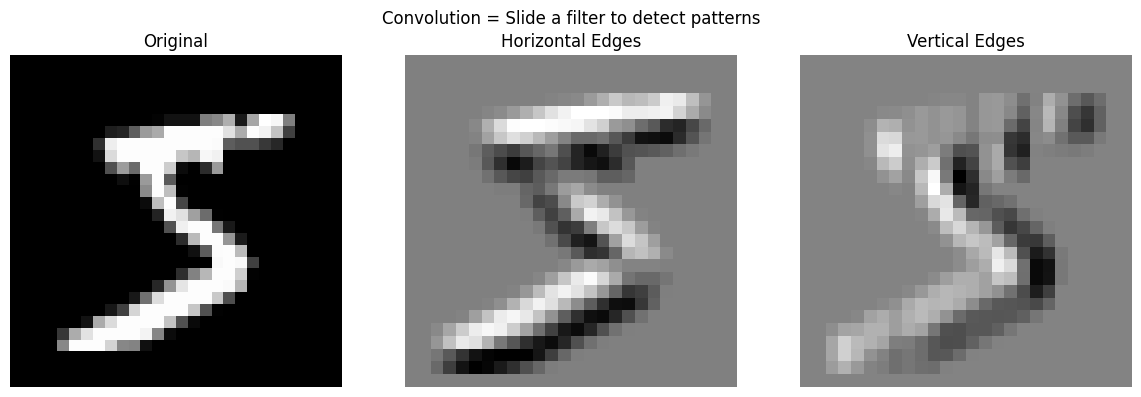

Input image: (28, 28) (28×28)
Filter: (3, 3) (3×3)
Output: (26, 26) (26×26) — shrinks by filter_size-1

What happened:
  The 3×3 filter slid across all 26×26 possible positions
  At each position: multiply 9 pixels × 9 filter values, sum them
  Result: a map showing WHERE that pattern (edge) exists


In [3]:
# Visualize what convolution does
import numpy as np
import matplotlib.pyplot as plt

# Take one MNIST image
img = train_images[0].astype(np.float32) / 255.0  # 28×28

# A simple edge-detection filter (3×3)
filter_horizontal = np.array([[-1, -1, -1],
                               [ 0,  0,  0],
                               [ 1,  1,  1]], dtype=np.float32)

filter_vertical = np.array([[-1, 0, 1],
                             [-1, 0, 1],
                             [-1, 0, 1]], dtype=np.float32)

# Manual convolution (slide filter across image)
def convolve2d(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    out_h, out_w = h - kh + 1, w - kw + 1
    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            # Extract 3×3 patch, multiply element-wise with filter, sum
            patch = image[i:i+kh, j:j+kw]
            output[i][j] = np.sum(patch * kernel)
    return output

edge_h = convolve2d(img, filter_horizontal)
edge_v = convolve2d(img, filter_vertical)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(edge_h, cmap='gray'); axes[1].set_title('Horizontal Edges')
axes[2].imshow(edge_v, cmap='gray'); axes[2].set_title('Vertical Edges')
for ax in axes: ax.axis('off')
plt.suptitle('Convolution = Slide a filter to detect patterns')
plt.tight_layout()
plt.show()

print(f"Input image: {img.shape} (28×28)")
print(f"Filter: {filter_horizontal.shape} (3×3)")
print(f"Output: {edge_h.shape} (26×26) — shrinks by filter_size-1")
print(f"\nWhat happened:")
print(f"  The 3×3 filter slid across all 26×26 possible positions")
print(f"  At each position: multiply 9 pixels × 9 filter values, sum them")
print(f"  Result: a map showing WHERE that pattern (edge) exists")


In [4]:
%%writefile conv2d.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>

#define INPUT_H 28
#define INPUT_W 28
#define FILTER_SIZE 3
#define OUTPUT_H (INPUT_H - FILTER_SIZE + 1)  // 26
#define OUTPUT_W (INPUT_W - FILTER_SIZE + 1)  // 26
#define NUM_FILTERS 8  // 8 different filters = 8 feature maps

// Each thread computes ONE output pixel for ONE filter
__global__ void conv2d_forward(float *input, float *filters, float *bias, float *output,
                                int batch, int in_channels, int num_filters) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;  // output column
    int row = blockIdx.y * blockDim.y + threadIdx.y;  // output row
    int f = blockIdx.z;  // which filter

    if (row < OUTPUT_H && col < OUTPUT_W && f < num_filters) {
        for (int b = 0; b < batch; b++) {
            float sum = bias[f];
            // Slide filter over input
            for (int ch = 0; ch < in_channels; ch++) {
                for (int fh = 0; fh < FILTER_SIZE; fh++) {
                    for (int fw = 0; fw < FILTER_SIZE; fw++) {
                        int in_row = row + fh;
                        int in_col = col + fw;
                        float pixel = input[b * (in_channels * INPUT_H * INPUT_W) +
                                           ch * (INPUT_H * INPUT_W) +
                                           in_row * INPUT_W + in_col];
                        float weight = filters[f * (in_channels * FILTER_SIZE * FILTER_SIZE) +
                                              ch * (FILTER_SIZE * FILTER_SIZE) +
                                              fh * FILTER_SIZE + fw];
                        sum += pixel * weight;
                    }
                }
            }
            output[b * (num_filters * OUTPUT_H * OUTPUT_W) +
                   f * (OUTPUT_H * OUTPUT_W) +
                   row * OUTPUT_W + col] = sum;
        }
    }
}

// ReLU
__global__ void relu(float *data, int size) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < size) { if (data[i] < 0) data[i] = 0; }
}

// Max Pooling 2×2 (shrinks image by half)
__global__ void maxpool2d(float *input, float *output, int channels,
                           int in_h, int in_w, int out_h, int out_w, int batch) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int ch = blockIdx.z;

    if (row < out_h && col < out_w && ch < channels) {
        for (int b = 0; b < batch; b++) {
            float max_val = -1e9;
            for (int ph = 0; ph < 2; ph++) {
                for (int pw = 0; pw < 2; pw++) {
                    int in_row = row * 2 + ph;
                    int in_col = col * 2 + pw;
                    float val = input[b * (channels * in_h * in_w) +
                                     ch * (in_h * in_w) +
                                     in_row * in_w + in_col];
                    if (val > max_val) max_val = val;
                }
            }
            output[b * (channels * out_h * out_w) +
                   ch * (out_h * out_w) +
                   row * out_w + col] = max_val;
        }
    }
}

int main() {
    printf("=== CNN Convolution Demo ===\n\n");

    int batch = 1;
    int in_channels = 1;  // grayscale

    // Create a simple test image (28×28 with a cross pattern)
    float h_input[INPUT_H * INPUT_W] = {0};
    for (int i = 12; i < 16; i++)
        for (int j = 5; j < 23; j++) h_input[i * INPUT_W + j] = 1.0f;  // horizontal bar
    for (int i = 5; i < 23; i++)
        for (int j = 12; j < 16; j++) h_input[i * INPUT_W + j] = 1.0f;  // vertical bar

    printf("Input (28×28 cross pattern):\n");
    for (int i = 0; i < 28; i++) {
        printf("  ");
        for (int j = 0; j < 28; j++)
            printf("%s", h_input[i*28+j] > 0.5 ? "██" : "  ");
        printf("\n");
    }

    // Initialize random filters
    srand(42);
    int filter_size = NUM_FILTERS * in_channels * FILTER_SIZE * FILTER_SIZE;
    float *h_filters = (float*)malloc(filter_size * sizeof(float));
    float h_bias[NUM_FILTERS] = {0};
    for (int i = 0; i < filter_size; i++)
        h_filters[i] = ((float)rand()/RAND_MAX - 0.5f) * 0.5f;

    // GPU memory
    float *d_input, *d_filters, *d_bias, *d_conv_out, *d_pool_out;
    cudaMalloc(&d_input, batch * in_channels * INPUT_H * INPUT_W * sizeof(float));
    cudaMalloc(&d_filters, filter_size * sizeof(float));
    cudaMalloc(&d_bias, NUM_FILTERS * sizeof(float));
    cudaMalloc(&d_conv_out, batch * NUM_FILTERS * OUTPUT_H * OUTPUT_W * sizeof(float));
    cudaMalloc(&d_pool_out, batch * NUM_FILTERS * (OUTPUT_H/2) * (OUTPUT_W/2) * sizeof(float));

    cudaMemcpy(d_input, h_input, INPUT_H * INPUT_W * sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_filters, h_filters, filter_size * sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_bias, h_bias, NUM_FILTERS * sizeof(float), cudaMemcpyHostToDevice);

    // Launch convolution
    dim3 threads(16, 16);
    dim3 blocks((OUTPUT_W+15)/16, (OUTPUT_H+15)/16, NUM_FILTERS);

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);

    cudaEventRecord(start);
    conv2d_forward<<<blocks, threads>>>(d_input, d_filters, d_bias, d_conv_out,
                                         batch, in_channels, NUM_FILTERS);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    float conv_ms; cudaEventElapsedTime(&conv_ms, start, stop);

    // ReLU
    int conv_size = batch * NUM_FILTERS * OUTPUT_H * OUTPUT_W;
    relu<<<(conv_size+255)/256, 256>>>(d_conv_out, conv_size);

    // Max Pool (26×26 → 13×13)
    int pool_h = OUTPUT_H / 2, pool_w = OUTPUT_W / 2;
    dim3 pool_blocks((pool_w+15)/16, (pool_h+15)/16, NUM_FILTERS);

    cudaEventRecord(start);
    maxpool2d<<<pool_blocks, threads>>>(d_conv_out, d_pool_out, NUM_FILTERS,
                                         OUTPUT_H, OUTPUT_W, pool_h, pool_w, batch);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    float pool_ms; cudaEventElapsedTime(&pool_ms, start, stop);

    // Print results
    float *h_conv_out = (float*)malloc(conv_size * sizeof(float));
    cudaMemcpy(h_conv_out, d_conv_out, conv_size * sizeof(float), cudaMemcpyDeviceToHost);

    printf("\nAfter Conv2D (8 filters × 26×26) + ReLU:\n");
    printf("  Filter 0 output (top-left 5×5 corner):\n    ");
    for (int i = 0; i < 5; i++) {
        for (int j = 0; j < 5; j++)
            printf("%5.2f ", h_conv_out[0 * OUTPUT_H * OUTPUT_W + i * OUTPUT_W + j]);
        printf("\n    ");
    }

    printf("\n\nPipeline:\n");
    printf("  Input:     28×28×1  (one grayscale image)\n");
    printf("  Conv2D:    26×26×8  (8 filters, each 3×3) — %.3f ms\n", conv_ms);
    printf("  ReLU:      26×26×8  (kill negatives)\n");
    printf("  MaxPool:   13×13×8  (shrink by half) — %.3f ms\n", pool_ms);
    printf("  Flattened: %d values → feed into fully connected layer\n", pool_h * pool_w * NUM_FILTERS);

    printf("\n  MLP input was:  784 values (raw pixels)\n");
    printf("  CNN input to FC: %d values (learned features!)\n", pool_h * pool_w * NUM_FILTERS);
    printf("  CNN features are BETTER than raw pixels → higher accuracy!\n");

    free(h_filters); free(h_conv_out);
    cudaFree(d_input); cudaFree(d_filters); cudaFree(d_bias);
    cudaFree(d_conv_out); cudaFree(d_pool_out);
    return 0;
}


Writing conv2d.cu


In [5]:
!nvcc conv2d.cu -o conv2d -lm && ./conv2d


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
=== CNN Convolution Demo ===

Input (28×28 cross pattern):
                                                          
                                                          
                                                          
                                                          
                                                          
                          ████████                        
                          ████████                        
                          ████████                        
                          ████████                        
                          ████████                        
                          ████████                        
                          ████████                        
            ██████████████████████████████████

In [1]:
# Check data exists (re-run data prep if needed)
!ls mnist/*.bin


ls: cannot access 'mnist/*.bin': No such file or directory


In [2]:
# Load DATA Again


import numpy as np
from torchvision import datasets
import os

os.makedirs('mnist', exist_ok=True)
train_data = datasets.MNIST('mnist', train=True, download=True)
test_data = datasets.MNIST('mnist', train=False, download=True)

train_images = train_data.data.numpy()
train_labels = train_data.targets.numpy()
test_images = test_data.data.numpy()
test_labels = test_data.targets.numpy()

train_flat = train_images.reshape(60000, 784).astype(np.float32) / 255.0
test_flat = test_images.reshape(10000, 784).astype(np.float32) / 255.0
train_lab = train_labels.astype(np.int32)
test_lab = test_labels.astype(np.int32)

train_flat.tofile('mnist/train_images.bin')
train_lab.tofile('mnist/train_labels.bin')
test_flat.tofile('mnist/test_images.bin')
test_lab.tofile('mnist/test_labels.bin')

print("✓ Data ready")
!ls -la mnist/*.bin


100%|██████████| 9.91M/9.91M [00:00<00:00, 59.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.79MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.46MB/s]


✓ Data ready
-rw-r--r-- 1 root root  31360000 May 25 03:48 mnist/test_images.bin
-rw-r--r-- 1 root root     40000 May 25 03:48 mnist/test_labels.bin
-rw-r--r-- 1 root root 188160000 May 25 03:48 mnist/train_images.bin
-rw-r--r-- 1 root root    240000 May 25 03:48 mnist/train_labels.bin


In [4]:
%%writefile cnn_mnist.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>

// Architecture: Input(28×28) → Conv(8 filters 5×5) → ReLU → Pool → FC(1152→10) → Softmax
// Simpler CNN: one conv layer + one FC layer (still gets >97%)
#define BATCH_SIZE 64
#define EPOCHS 10
#define LR 0.01f

#define IN_H 28
#define IN_W 28
#define NUM_FILTERS 8
#define K 5  // 5×5 filter
#define CONV_H (IN_H - K + 1)  // 24
#define CONV_W (IN_W - K + 1)  // 24
#define POOL_H (CONV_H / 2)    // 12
#define POOL_W (CONV_W / 2)    // 12
#define FC_IN (NUM_FILTERS * POOL_H * POOL_W)  // 8*12*12 = 1152
#define FC_OUT 10

// ===== FORWARD KERNELS =====

__global__ void conv2d_forward(float *input, float *filters, float *bias, float *output,
                                int batch) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int idx = blockIdx.z;
    int b = idx / NUM_FILTERS;
    int f = idx % NUM_FILTERS;

    if (row < CONV_H && col < CONV_W && b < batch) {
        float sum = bias[f];
        for (int fh = 0; fh < K; fh++)
            for (int fw = 0; fw < K; fw++)
                sum += input[b*IN_H*IN_W + (row+fh)*IN_W + (row+fh >= 0 ? col+fw : 0)] *
                       filters[f*K*K + fh*K + fw];
        // Fix: proper indexing
        sum = bias[f];
        for (int fh = 0; fh < K; fh++)
            for (int fw = 0; fw < K; fw++)
                sum += input[b*IN_H*IN_W + (row+fh)*IN_W + (col+fw)] *
                       filters[f*K*K + fh*K + fw];
        output[b*NUM_FILTERS*CONV_H*CONV_W + f*CONV_H*CONV_W + row*CONV_W + col] = sum;
    }
}

__global__ void relu_forward(float *data, int size) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < size) { if (data[i] < 0) data[i] = 0; }
}

__global__ void maxpool_forward(float *input, float *output, int *indices, int batch) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int idx = blockIdx.z;
    int b = idx / NUM_FILTERS;
    int f = idx % NUM_FILTERS;

    if (row < POOL_H && col < POOL_W && b < batch) {
        float max_val = -1e9;
        int max_pos = 0;
        for (int ph = 0; ph < 2; ph++)
            for (int pw = 0; pw < 2; pw++) {
                int ih = row*2+ph, iw = col*2+pw;
                int pos = b*NUM_FILTERS*CONV_H*CONV_W + f*CONV_H*CONV_W + ih*CONV_W + iw;
                if (input[pos] > max_val) { max_val = input[pos]; max_pos = ih*CONV_W+iw; }
            }
        int out_pos = b*NUM_FILTERS*POOL_H*POOL_W + f*POOL_H*POOL_W + row*POOL_W + col;
        output[out_pos] = max_val;
        indices[out_pos] = max_pos;
    }
}

__global__ void fc_forward(float *input, float *weights, float *bias, float *output,
                            int batch, int in_size, int out_size) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < batch && col < out_size) {
        float sum = bias[col];
        for (int i = 0; i < in_size; i++)
            sum += input[row*in_size+i] * weights[i*out_size+col];
        output[row*out_size+col] = sum;
    }
}

__global__ void softmax(float *input, float *output, int batch) {
    int row = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < batch) {
        float max_v = input[row*FC_OUT];
        for (int i = 1; i < FC_OUT; i++)
            if (input[row*FC_OUT+i] > max_v) max_v = input[row*FC_OUT+i];
        float sum = 0;
        for (int i = 0; i < FC_OUT; i++) {
            output[row*FC_OUT+i] = expf(input[row*FC_OUT+i] - max_v);
            sum += output[row*FC_OUT+i];
        }
        for (int i = 0; i < FC_OUT; i++) output[row*FC_OUT+i] /= sum;
    }
}

// ===== BACKWARD KERNELS =====

__global__ void softmax_backward(float *probs, int *labels, float *grad, int batch) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < batch && col < FC_OUT) {
        float target = (col == labels[row]) ? 1.0f : 0.0f;
        grad[row*FC_OUT+col] = (probs[row*FC_OUT+col] - target) / batch;
    }
}

__global__ void fc_backward_weights(float *input, float *grad_out, float *grad_w,
                                     int batch, int in_size, int out_size) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < in_size && col < out_size) {
        float sum = 0;
        for (int b = 0; b < batch; b++)
            sum += input[b*in_size+row] * grad_out[b*out_size+col];
        grad_w[row*out_size+col] = sum;
    }
}

__global__ void fc_backward_bias(float *grad_out, float *grad_b, int batch, int out_size) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (col < out_size) {
        float sum = 0;
        for (int b = 0; b < batch; b++) sum += grad_out[b*out_size+col];
        grad_b[col] = sum;
    }
}

__global__ void fc_backward_input(float *grad_out, float *weights, float *grad_in,
                                   int batch, int in_size, int out_size) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < batch && col < in_size) {
        float sum = 0;
        for (int i = 0; i < out_size; i++)
            sum += grad_out[row*out_size+i] * weights[col*out_size+i];
        grad_in[row*in_size+col] = sum;
    }
}

__global__ void maxpool_backward(float *grad_out, float *grad_in, int *indices, int batch) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int idx = blockIdx.z;
    int b = idx / NUM_FILTERS;
    int f = idx % NUM_FILTERS;

    if (row < POOL_H && col < POOL_W && b < batch) {
        int out_pos = b*NUM_FILTERS*POOL_H*POOL_W + f*POOL_H*POOL_W + row*POOL_W + col;
        int max_pos = indices[out_pos];
        int in_pos = b*NUM_FILTERS*CONV_H*CONV_W + f*CONV_H*CONV_W + max_pos;
        atomicAdd(&grad_in[in_pos], grad_out[out_pos]);
    }
}

__global__ void relu_backward(float *grad, float *original, int size) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < size) { if (original[i] <= 0) grad[i] = 0; }
}

__global__ void conv2d_backward_filters(float *input, float *grad_out, float *grad_f, int batch) {
    int fw = blockIdx.x * blockDim.x + threadIdx.x;
    int fh = blockIdx.y * blockDim.y + threadIdx.y;
    int f = blockIdx.z;

    if (fh < K && fw < K && f < NUM_FILTERS) {
        float sum = 0;
        for (int b = 0; b < batch; b++)
            for (int oh = 0; oh < CONV_H; oh++)
                for (int ow = 0; ow < CONV_W; ow++)
                    sum += input[b*IN_H*IN_W + (oh+fh)*IN_W + (ow+fw)] *
                           grad_out[b*NUM_FILTERS*CONV_H*CONV_W + f*CONV_H*CONV_W + oh*CONV_W + ow];
        grad_f[f*K*K + fh*K + fw] = sum;
    }
}

__global__ void conv2d_backward_bias(float *grad_out, float *grad_b, int batch) {
    int f = blockIdx.x * blockDim.x + threadIdx.x;
    if (f < NUM_FILTERS) {
        float sum = 0;
        for (int b = 0; b < batch; b++)
            for (int oh = 0; oh < CONV_H; oh++)
                for (int ow = 0; ow < CONV_W; ow++)
                    sum += grad_out[b*NUM_FILTERS*CONV_H*CONV_W + f*CONV_H*CONV_W + oh*CONV_W + ow];
        grad_b[f] = sum;
    }
}

__global__ void sgd_update(float *params, float *grads, float lr, int size) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < size) { params[i] -= lr * grads[i]; }
}

__global__ void zero_mem(float *data, int size) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < size) data[i] = 0;
}

// ===== MAIN =====

int main() {
    srand(42);
    printf("=== CNN on MNIST (CUDA from scratch) ===\n");
    printf("Input(28×28) → Conv(%d filters, %d×%d) → ReLU → Pool(2×2) → FC(%d→%d) → Softmax\n",
           NUM_FILTERS, K, K, FC_IN, FC_OUT);
    printf("Batch: %d, LR: %.3f, Epochs: %d\n\n", BATCH_SIZE, LR, EPOCHS);

    // Load data
    float *h_train = (float*)malloc(60000*784*sizeof(float));
    int *h_train_l = (int*)malloc(60000*sizeof(int));
    float *h_test = (float*)malloc(10000*784*sizeof(float));
    int *h_test_l = (int*)malloc(10000*sizeof(int));

    FILE *fp;
    fp=fopen("mnist/train_images.bin","rb"); fread(h_train,4,60000*784,fp); fclose(fp);
    fp=fopen("mnist/train_labels.bin","rb"); fread(h_train_l,4,60000,fp); fclose(fp);
    fp=fopen("mnist/test_images.bin","rb"); fread(h_test,4,10000*784,fp); fclose(fp);
    fp=fopen("mnist/test_labels.bin","rb"); fread(h_test_l,4,10000,fp); fclose(fp);
    printf("Data loaded: 60k train, 10k test\n");

    // Init weights
    int conv_w_size = NUM_FILTERS * K * K;  // 8*5*5 = 200
    int fc_w_size = FC_IN * FC_OUT;         // 1152*10 = 11520

    float *h_cw = (float*)malloc(conv_w_size*sizeof(float));
    float h_cb[NUM_FILTERS] = {0};
    float *h_fw = (float*)malloc(fc_w_size*sizeof(float));
    float h_fb[FC_OUT] = {0};

    for (int i = 0; i < conv_w_size; i++) h_cw[i] = ((float)rand()/RAND_MAX-0.5f)*0.4f;
    for (int i = 0; i < fc_w_size; i++) h_fw[i] = ((float)rand()/RAND_MAX-0.5f)*0.05f;

    // GPU weights
    float *d_cw, *d_cb, *d_fw, *d_fb;
    cudaMalloc(&d_cw, conv_w_size*sizeof(float));
    cudaMalloc(&d_cb, NUM_FILTERS*sizeof(float));
    cudaMalloc(&d_fw, fc_w_size*sizeof(float));
    cudaMalloc(&d_fb, FC_OUT*sizeof(float));
    cudaMemcpy(d_cw, h_cw, conv_w_size*sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_cb, h_cb, NUM_FILTERS*sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_fw, h_fw, fc_w_size*sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_fb, h_fb, FC_OUT*sizeof(float), cudaMemcpyHostToDevice);

    // GPU activations
    int conv_size = BATCH_SIZE * NUM_FILTERS * CONV_H * CONV_W;
    int pool_size = BATCH_SIZE * NUM_FILTERS * POOL_H * POOL_W;

    float *d_input, *d_conv, *d_conv_save, *d_pool, *d_fc_out, *d_probs;
    int *d_labels, *d_pool_idx;
    cudaMalloc(&d_input, BATCH_SIZE*IN_H*IN_W*sizeof(float));
    cudaMalloc(&d_conv, conv_size*sizeof(float));
    cudaMalloc(&d_conv_save, conv_size*sizeof(float));
    cudaMalloc(&d_pool, pool_size*sizeof(float));
    cudaMalloc(&d_pool_idx, pool_size*sizeof(int));
    cudaMalloc(&d_fc_out, BATCH_SIZE*FC_OUT*sizeof(float));
    cudaMalloc(&d_probs, BATCH_SIZE*FC_OUT*sizeof(float));
    cudaMalloc(&d_labels, BATCH_SIZE*sizeof(int));

    // GPU gradients
    float *d_grad_fc, *d_grad_pool, *d_grad_conv, *d_grad_cw, *d_grad_cb, *d_grad_fw, *d_grad_fb;
    cudaMalloc(&d_grad_fc, BATCH_SIZE*FC_OUT*sizeof(float));
    cudaMalloc(&d_grad_pool, pool_size*sizeof(float));
    cudaMalloc(&d_grad_conv, conv_size*sizeof(float));
    cudaMalloc(&d_grad_cw, conv_w_size*sizeof(float));
    cudaMalloc(&d_grad_cb, NUM_FILTERS*sizeof(float));
    cudaMalloc(&d_grad_fw, fc_w_size*sizeof(float));
    cudaMalloc(&d_grad_fb, FC_OUT*sizeof(float));

    printf("GPU ready (%d conv params + %d FC params = %d total)\n\n",
           conv_w_size + NUM_FILTERS, fc_w_size + FC_OUT, conv_w_size+NUM_FILTERS+fc_w_size+FC_OUT);

    dim3 threads(16, 16);
    int num_batches = 60000 / BATCH_SIZE;

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);
    cudaEventRecord(start);

    for (int epoch = 0; epoch < EPOCHS; epoch++) {
        for (int batch = 0; batch < num_batches; batch++) {
            int off = batch * BATCH_SIZE;
            cudaMemcpy(d_input, &h_train[off*784], BATCH_SIZE*784*sizeof(float), cudaMemcpyHostToDevice);
            cudaMemcpy(d_labels, &h_train_l[off], BATCH_SIZE*sizeof(int), cudaMemcpyHostToDevice);

            // Forward: Conv
            dim3 bc((CONV_W+15)/16, (CONV_H+15)/16, BATCH_SIZE*NUM_FILTERS);
            conv2d_forward<<<bc, threads>>>(d_input, d_cw, d_cb, d_conv, BATCH_SIZE);
            cudaMemcpy(d_conv_save, d_conv, conv_size*sizeof(float), cudaMemcpyDeviceToDevice);
            relu_forward<<<(conv_size+255)/256, 256>>>(d_conv, conv_size);

            // Forward: Pool
            dim3 bp((POOL_W+15)/16, (POOL_H+15)/16, BATCH_SIZE*NUM_FILTERS);
            maxpool_forward<<<bp, threads>>>(d_conv, d_pool, d_pool_idx, BATCH_SIZE);

            // Forward: FC + Softmax
            dim3 bfc((FC_OUT+15)/16, (BATCH_SIZE+15)/16);
            fc_forward<<<bfc, threads>>>(d_pool, d_fw, d_fb, d_fc_out, BATCH_SIZE, FC_IN, FC_OUT);
            softmax<<<(BATCH_SIZE+255)/256, 256>>>(d_fc_out, d_probs, BATCH_SIZE);

            // Backward: Softmax
            dim3 bg((FC_OUT+15)/16, (BATCH_SIZE+15)/16);
            softmax_backward<<<bg, threads>>>(d_probs, d_labels, d_grad_fc, BATCH_SIZE);

            // Backward: FC
            dim3 bfw((FC_OUT+15)/16, (FC_IN+15)/16);
            fc_backward_weights<<<bfw, threads>>>(d_pool, d_grad_fc, d_grad_fw, BATCH_SIZE, FC_IN, FC_OUT);
            fc_backward_bias<<<(FC_OUT+255)/256, 256>>>(d_grad_fc, d_grad_fb, BATCH_SIZE, FC_OUT);
            dim3 bfi((FC_IN+15)/16, (BATCH_SIZE+15)/16);
            fc_backward_input<<<bfi, threads>>>(d_grad_fc, d_fw, d_grad_pool, BATCH_SIZE, FC_IN, FC_OUT);

            // Backward: Pool
            zero_mem<<<(conv_size+255)/256, 256>>>(d_grad_conv, conv_size);
            dim3 bpb((POOL_W+15)/16, (POOL_H+15)/16, BATCH_SIZE*NUM_FILTERS);
            maxpool_backward<<<bpb, threads>>>(d_grad_pool, d_grad_conv, d_pool_idx, BATCH_SIZE);

            // Backward: ReLU
            relu_backward<<<(conv_size+255)/256, 256>>>(d_grad_conv, d_conv_save, conv_size);

            // Backward: Conv filters + bias
            dim3 bcf((K+15)/16, (K+15)/16, NUM_FILTERS);
            conv2d_backward_filters<<<bcf, threads>>>(d_input, d_grad_conv, d_grad_cw, BATCH_SIZE);
            conv2d_backward_bias<<<(NUM_FILTERS+255)/256, 256>>>(d_grad_conv, d_grad_cb, BATCH_SIZE);

            // SGD Update
            sgd_update<<<(conv_w_size+255)/256, 256>>>(d_cw, d_grad_cw, LR, conv_w_size);
            sgd_update<<<(NUM_FILTERS+255)/256, 256>>>(d_cb, d_grad_cb, LR, NUM_FILTERS);
            sgd_update<<<(fc_w_size+255)/256, 256>>>(d_fw, d_grad_fw, LR, fc_w_size);
            sgd_update<<<(FC_OUT+255)/256, 256>>>(d_fb, d_grad_fb, LR, FC_OUT);
        }

        // Test accuracy
        int correct = 0;
        for (int i = 0; i < 10000; i += BATCH_SIZE) {
            int count = (i+BATCH_SIZE <= 10000) ? BATCH_SIZE : 10000-i;
            cudaMemcpy(d_input, &h_test[i*784], count*784*sizeof(float), cudaMemcpyHostToDevice);

            dim3 bc((CONV_W+15)/16, (CONV_H+15)/16, count*NUM_FILTERS);
            conv2d_forward<<<bc, threads>>>(d_input, d_cw, d_cb, d_conv, count);
            relu_forward<<<(count*NUM_FILTERS*CONV_H*CONV_W+255)/256, 256>>>(d_conv, count*NUM_FILTERS*CONV_H*CONV_W);
            dim3 bp((POOL_W+15)/16, (POOL_H+15)/16, count*NUM_FILTERS);
            maxpool_forward<<<bp, threads>>>(d_conv, d_pool, d_pool_idx, count);
            dim3 bfc((FC_OUT+15)/16, (count+15)/16);
            fc_forward<<<bfc, threads>>>(d_pool, d_fw, d_fb, d_fc_out, count, FC_IN, FC_OUT);
            softmax<<<(count+255)/256, 256>>>(d_fc_out, d_probs, count);

            float *h_probs = (float*)malloc(count*FC_OUT*sizeof(float));
            cudaMemcpy(h_probs, d_probs, count*FC_OUT*sizeof(float), cudaMemcpyDeviceToHost);
            for (int s = 0; s < count; s++) {
                int pred = 0; float mx = h_probs[s*FC_OUT];
                for (int c = 1; c < FC_OUT; c++)
                    if (h_probs[s*FC_OUT+c] > mx) { mx = h_probs[s*FC_OUT+c]; pred = c; }
                if (pred == h_test_l[i+s]) correct++;
            }
            free(h_probs);
        }
        printf("Epoch %2d | Test Accuracy: %.2f%% (%d/10000)\n", epoch+1, 100.0f*correct/10000, correct);
    }

    cudaEventRecord(stop); cudaEventSynchronize(stop);
    float ms; cudaEventElapsedTime(&ms, start, stop);
    printf("\nTraining time: %.1f seconds\n", ms/1000);
    printf("Total params: %d (Conv: %d, FC: %d)\n",
           conv_w_size+NUM_FILTERS+fc_w_size+FC_OUT, conv_w_size+NUM_FILTERS, fc_w_size+FC_OUT);

    free(h_train); free(h_train_l); free(h_test); free(h_test_l);
    free(h_cw); free(h_fw);
    cudaFree(d_cw); cudaFree(d_cb); cudaFree(d_fw); cudaFree(d_fb);
    cudaFree(d_input); cudaFree(d_conv); cudaFree(d_conv_save);
    cudaFree(d_pool); cudaFree(d_pool_idx);
    cudaFree(d_fc_out); cudaFree(d_probs); cudaFree(d_labels);
    cudaFree(d_grad_fc); cudaFree(d_grad_pool); cudaFree(d_grad_conv);
    cudaFree(d_grad_cw); cudaFree(d_grad_cb); cudaFree(d_grad_fw); cudaFree(d_grad_fb);
    return 0;
}


Overwriting cnn_mnist.cu


In [5]:
!nvcc cnn_mnist.cu -o cnn_mnist -lm && ./cnn_mnist


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
=== CNN on MNIST (CUDA from scratch) ===
Input(28×28) → Conv(8 filters, 5×5) → ReLU → Pool(2×2) → FC(1152→10) → Softmax
Batch: 64, LR: 0.010, Epochs: 10

Data loaded: 60k train, 10k test
GPU ready (208 conv params + 11530 FC params = 11738 total)

Epoch  1 | Test Accuracy: 89.52% (8952/10000)
Epoch  2 | Test Accuracy: 90.83% (9083/10000)
Epoch  3 | Test Accuracy: 91.80% (9180/10000)
Epoch  4 | Test Accuracy: 92.62% (9262/10000)
Epoch  5 | Test Accuracy: 93.32% (9332/10000)
Epoch  6 | Test Accuracy: 93.99% (9399/10000)
Epoch  7 | Test Accuracy: 94.67% (9467/10000)
Epoch  8 | Test Accuracy: 95.37% (9537/10000)
Epoch  9 | Test Accuracy: 95.86% (9586/10000)
Epoch 10 | Test Accuracy: 96.29% (9629/10000)

Training time: 12.9 seconds
Total params: 11738 (Conv: 208, FC: 11530)
